# Energy champions — feature importance (train-only)

All values generated from `selection_table.csv` and per-instrument artifacts. Train data only; the 30% test set is **sealed**.

> **ho1s** and **ng1s** have MLP champions in `selection_table.csv`; their importance artifacts were computed with a different model family — see the `⚠️` warning in the intro table and the assertion output.

In [ ]:
from pathlib import Path
import math
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

SEL_PATH = Path('outputs/model_comparison/selection_table.csv')
BASE     = Path('outputs/importance')

sel = pd.read_csv(SEL_PATH).set_index('instrument')

# ── helpers ────────────────────────────────────────────────────────────────

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def get_meta(inst):
    m = load(BASE / inst / 'champion_meta.csv')
    return m.iloc[0].to_dict() if not m.empty else {}

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members   =('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity      =('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    return (
        grp.merge(mda[['cluster', 'mean_drop', 'std_drop', 'significant']],
                  on='cluster', how='left')
        .sort_values('mean_drop', ascending=False)
    )

def top_n_clusters(inst, n=3):
    """Significant clusters first (MDA desc), then non-significant (MDA desc); take n."""
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        return []
    sig = mda[mda['significant']].sort_values('mean_drop', ascending=False)
    non = mda[~mda['significant']].sort_values('mean_drop', ascending=False)
    return pd.concat([sig, non])['cluster'].head(n).tolist()

def pick_score_col(wc, family):
    if family == 'logistic' and 'mean_coef_abs' in wc.columns:
        return 'mean_coef_abs', '|coef|'
    for col, lbl in [('mean_shap_mag', '|SHAP|'),
                     ('mean_perm_imp', '|Perm|'),
                     ('mean_coef_abs', '|coef|')]:
        if col in wc.columns:
            return col, lbl
    return wc.columns[2], wc.columns[2]

def print_header(inst):
    """Print section header from champion_meta; return meta dict."""
    meta    = get_meta(inst)
    mda_df  = load(BASE / inst / 'clustered_mda_full.csv')
    sig     = mda_df[mda_df['significant']] if not mda_df.empty else pd.DataFrame()
    sig_str = (
        ', '.join(f"{r['cluster']} (MDA {r['mean_drop']:.4f} \u00b1 {r['std_drop']:.4f})"
                  for _, r in sig.iterrows())
        or 'none'
    )
    family  = meta.get('family', 'tree')
    model   = meta.get('model_type', '?').upper()
    auc     = meta.get('auc_mean', float('nan'))
    std     = meta.get('auc_std',  float('nan'))
    lci     = meta.get('lower_ci', float('nan'))
    signal  = bool(meta.get('signal', False))
    grp     = meta.get('group', '?')
    n_folds = int(meta.get('n_folds', 0))
    print(f'--- {inst.upper()} | group={grp} | champion={model} | family={family} ---')
    print(f'CPCV: {n_folds} paths  AUC {auc:.4f} \u00b1 {std:.4f}  '
          f'AUC lower CI {lci:.4f}')
    print(f'Significant clusters: {sig_str}')
    return meta

def show_within_cluster(inst, cluster_name, family):
    wc = load(BASE / inst / f'within_cluster_{cluster_name}.csv')
    if wc.empty:
        return
    pc1 = wc['pca_pc1_var_explained'].iloc[0] if 'pca_pc1_var_explained' in wc.columns else float('nan')
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = ('>= 65% single latent' if pc1 >= 0.65 else
            ('>= 40% dominant'     if pc1 >= 0.40 else '< 40% multi-dim'))
    pc2_s   = f' PC2={pc2:.1%}' if math.isfinite(pc2) else ''
    pca_lbl = f'PC1={pc1:.1%}{pc2_s} ({tier})' if math.isfinite(pc1) else 'no PCA'
    col, col_lbl = pick_score_col(wc, family)
    display(
        wc[['feature', col, 'pc1_loading']].style
        .format({col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[col], cmap='Blues')
        .set_caption(f'{inst} | {cluster_name} — {col_lbl} ranking + PC1 loadings  ({pca_lbl})')
    )
    show(BASE / inst / f'within_cluster_{cluster_name}.png', width=950)

def show_step1(inst):
    cs = cluster_summary(inst)
    if not cs.empty:
        rng = max(cs['mean_drop'].abs().max() * 1.1, 0.005)
        display(
            cs.style
            .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
            .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster summary')
        )
    show(BASE / inst / 'dendrogram.png', width=1100)

def show_step2(inst):
    show(BASE / inst / 'clustered_mda_chart.png', width=1050)
    cc = load(BASE / inst / 'cluster_crosscheck_table.csv')
    ra = load(BASE / inst / 'rank_agreement.csv')
    if not cc.empty:
        fmt = {'mda_mean': '{:.4f}'}
        for c in ('mdi_sum', 'shap_sum', 'coef_sum', 'perm_sum'):
            if c in cc.columns:
                fmt[c] = '{:.4f}'
        rng = max(cc['mda_mean'].abs().max() * 1.2, 0.005)
        display(
            cc.style.format(fmt)
            .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-rng, vmax=rng)
            .set_caption(f'{inst} — cluster cross-check')
        )
    if not ra.empty:
        print('\nKendall \u03c4 rank agreement:')
        display(ra.style.format({'kendall_tau': '{:.2f}'}))

def show_step3(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    top3   = top_n_clusters(inst, n=3)
    print(f'Step-3 clusters (significant first): {top3}')
    for c in top3:
        show_within_cluster(inst, c, family)

def show_step5(inst):
    meta   = get_meta(inst)
    family = meta.get('family', 'tree')
    if family == 'logistic':
        g = load(BASE / inst / 'global_coef_summary.csv')
        if not g.empty:
            sc  = 'coef_abs' if 'coef_abs' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            if 'coef_signed' in g.columns:
                fmt['coef_signed'] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |coef|')
            )
        show(BASE / inst / 'global_coef_chart.png', width=1000)
    else:
        g = load(BASE / inst / 'global_shap_summary.csv')
        if not g.empty:
            sc  = 'shap_magnitude' if 'shap_magnitude' in g.columns else g.columns[1]
            fmt = {sc: '{:.4f}'}
            for c in ('shap_signed', 'mdi'):
                if c in g.columns:
                    fmt[c] = '{:.4f}'
            display(
                g.head(25).style.format(fmt)
                .background_gradient(subset=[sc], cmap='Blues')
                .set_caption(f'{inst} — top 25 features by mean |SHAP|')
            )
        show(BASE / inst / 'global_shap_chart.png', width=1000)

print('Setup complete.  Artifact root:', BASE.resolve())
print('Selection table:', len(sel), 'instruments')


In [ ]:
# Intro champion table — all values from selection_table + champion_meta
INSTS = ['cl1s', 'ho1s', 'rb1s', 'ng1s']

rows = []
for inst in INSTS:
    m = get_meta(inst)
    s = sel.loc[inst]
    rows.append({
        'Instrument': inst,
        'Group'     : m.get('group',      s['best_group']),
        'Family'    : m.get('family',     s['best_model']),
        'Champion'  : m.get('model_type', s['best_model']).upper(),
        'AUC'       : f"{m.get('auc_mean', s['best_auc']):.3f}\u00b1{m.get('auc_std', 0):.3f}",
        'Lower CI'  : f"{m.get('lower_ci', s['lower_ci']):.4f}",
        'Signal'    : '\u2713' if m.get('signal', bool(s['signal'])) else '\u2717',
    })

intro_df = pd.DataFrame(rows)
display(
    intro_df.style
    .set_caption('Energy champions — source: selection_table.csv \u2192 champion_meta.csv')
    .hide(axis='index')
)

# Warn about MLP instruments (artifacts may have been computed with a different model)
for inst in INSTS:
    s = sel.loc[inst]
    m = get_meta(inst)
    if s['best_model'] == 'mlp' and m.get('model_type', '') != 'mlp':
        print(f'\u26a0\ufe0f  {inst}: selection_table champion=MLP but champion_meta shows '
              f'{m.get("model_type","?")}.  Importance artifacts may be from the runner-up model.')


---
### CL1S — Steps 1–5

In [ ]:
meta = print_header('cl1s')

#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
7,C2_f11_lowfreq_macro,2,f11_,100%,0.0122,0.0089,True
4,C14_f12,2,f12_,100%,0.0116,0.0100,True
3,C13_f11,7,f11_,71%,0.0102,0.0163,False
14,C9_f2,8,f2_,62%,0.0088,0.0175,False
2,C12_f2,11,f2_,36%,0.0077,0.0209,False
8,C3_f11,9,f11_,78%,0.0067,0.0177,False
17,F8_calendar,4,f8_,100%,0.0049,0.0054,False
1,C11_f11_lowfreq_macro,2,f11_,100%,0.0045,0.0053,False
0,C10_f7,2,f7_,100%,0.0019,0.0070,False
5,C15_f7,3,f7_,100%,0.0016,0.0066,False


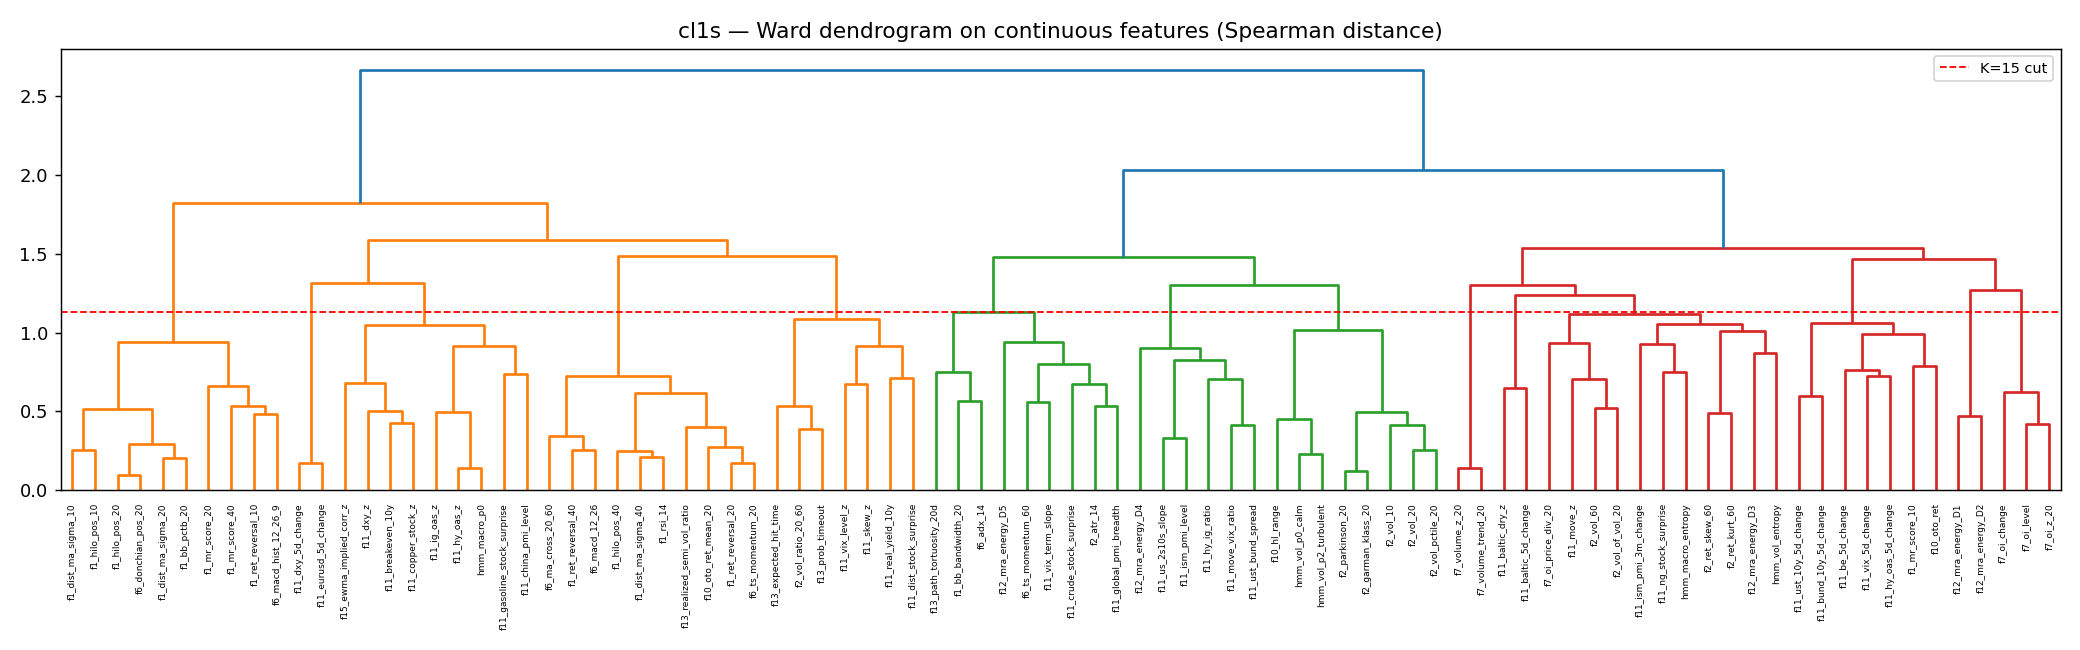

In [4]:
show_step1('cl1s')

#### Step 2 · Cluster-level importance

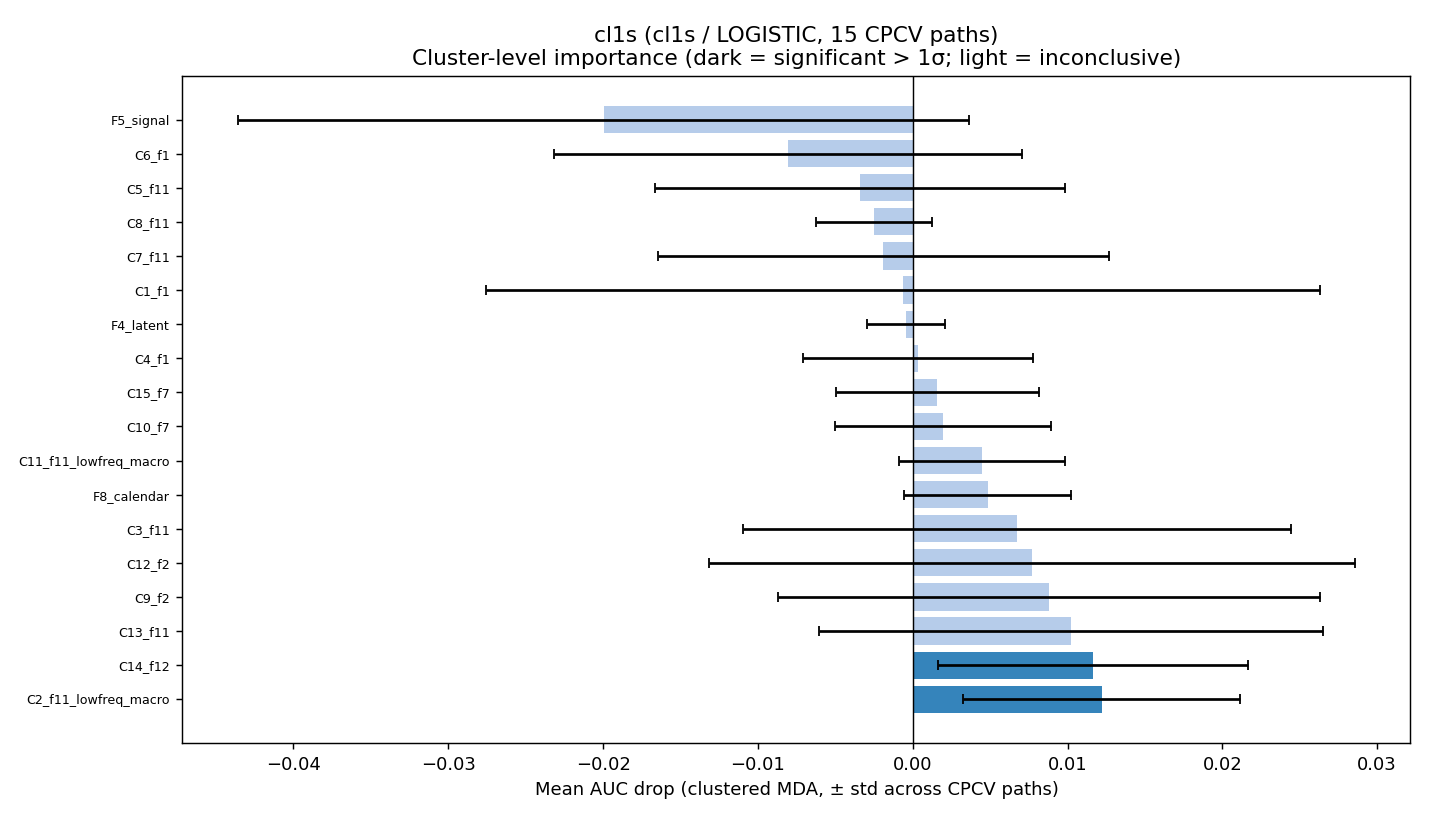

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,C2_f11_lowfreq_macro,0.0122,1,0.1727,11,True
1,C14_f12,0.0116,2,0.1503,14,True
2,C13_f11,0.0102,3,0.5024,3,False
3,C9_f2,0.0088,4,0.3043,7,False
4,C12_f2,0.0077,5,0.8473,1,False
5,C3_f11,0.0067,6,0.5282,2,False
6,F8_calendar,0.0049,7,0.2047,10,False
7,C11_f11_lowfreq_macro,0.0045,8,0.1520,13,False
8,C10_f7,0.0019,9,0.0741,17,False
9,C15_f7,0.0016,10,0.1317,16,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-Coef,0.10,False


In [5]:
show_step2('cl1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C2_f11_lowfreq_macro', 'C14_f12', 'C13_f11']


,feature,mean_coef_abs,pc1_loading
0,f11_dxy_5d_change,0.1182,0.707
1,f11_eurusd_5d_change,0.0545,-0.707


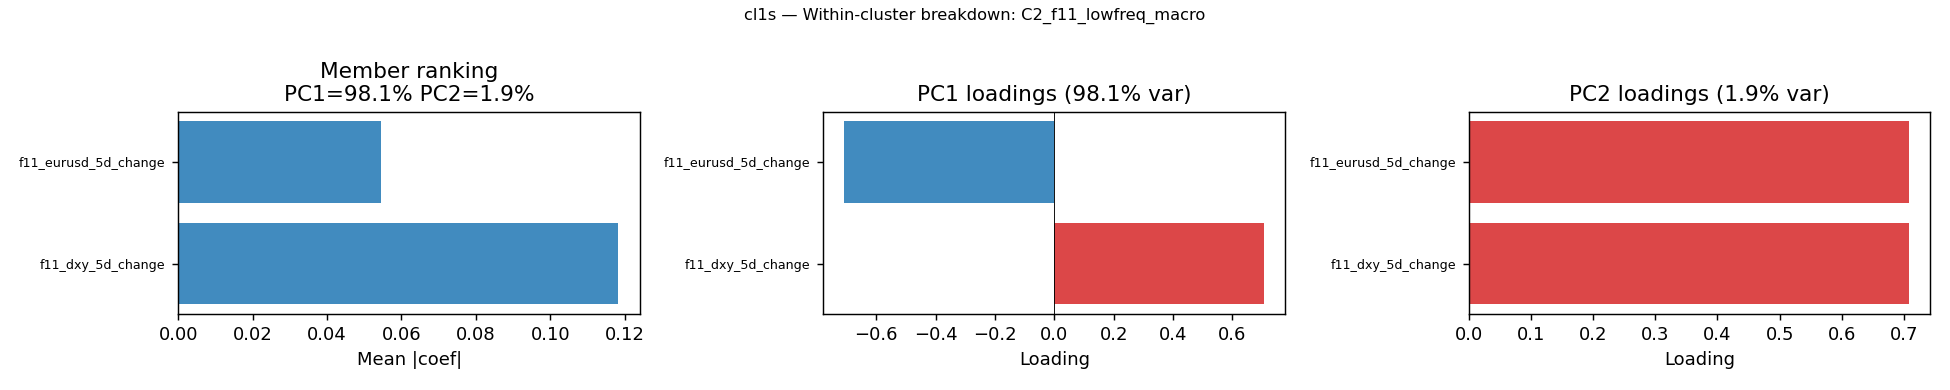

,feature,mean_coef_abs,pc1_loading
0,f12_mra_energy_D1,0.0815,-0.707
1,f12_mra_energy_D2,0.0688,0.707


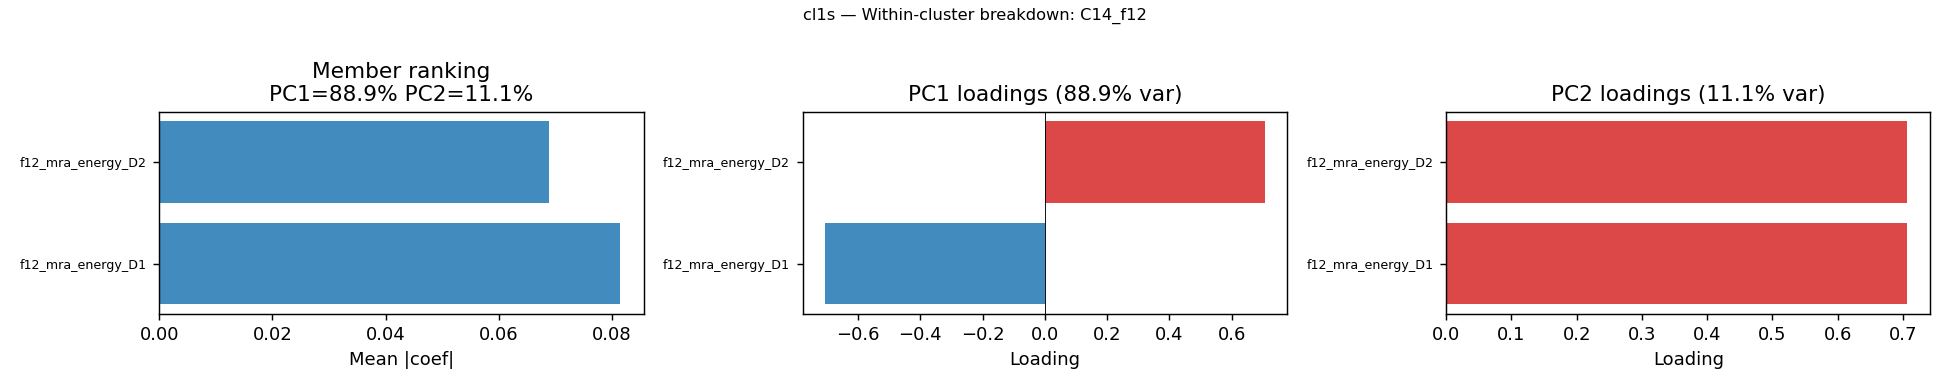

,feature,mean_coef_abs,pc1_loading
0,f1_mr_score_10,0.1251,0.421
1,f10_oto_ret,0.0769,-0.191
2,f11_vix_5d_change,0.0463,0.470
3,f11_ust_10y_5d_change,0.0689,-0.431
4,f11_bund_10y_5d_change,0.0789,-0.285
5,f11_be_5d_change,0.0643,-0.435
6,f11_hy_oas_5d_change,0.0109,0.329


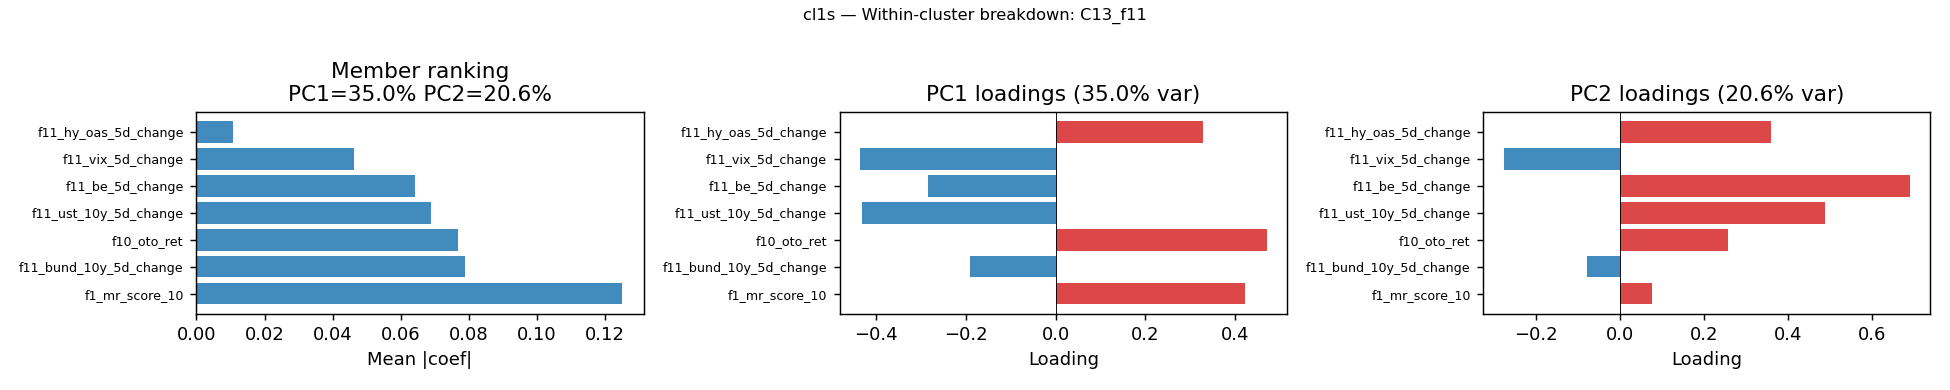

In [6]:
show_step3('cl1s')

#### Step 5 · Global feature importance

,feature,coef_abs,coef_signed
0,f11_crude_stock_surprise,0.1433,-0.1433
1,f2_vol_10,0.1377,0.1377
2,f2_ret_skew_60,0.1369,0.1369
3,f11_china_pmi_level,0.1323,-0.1323
4,f1_mr_score_10,0.1251,0.1251
5,f8_dow_cos,0.1222,0.1222
6,f11_dxy_5d_change,0.1182,0.1182
7,hmm_macro_entropy,0.1109,0.1109
8,f11_move_z,0.1087,-0.1087
9,f11_baltic_5d_change,0.1022,0.1022


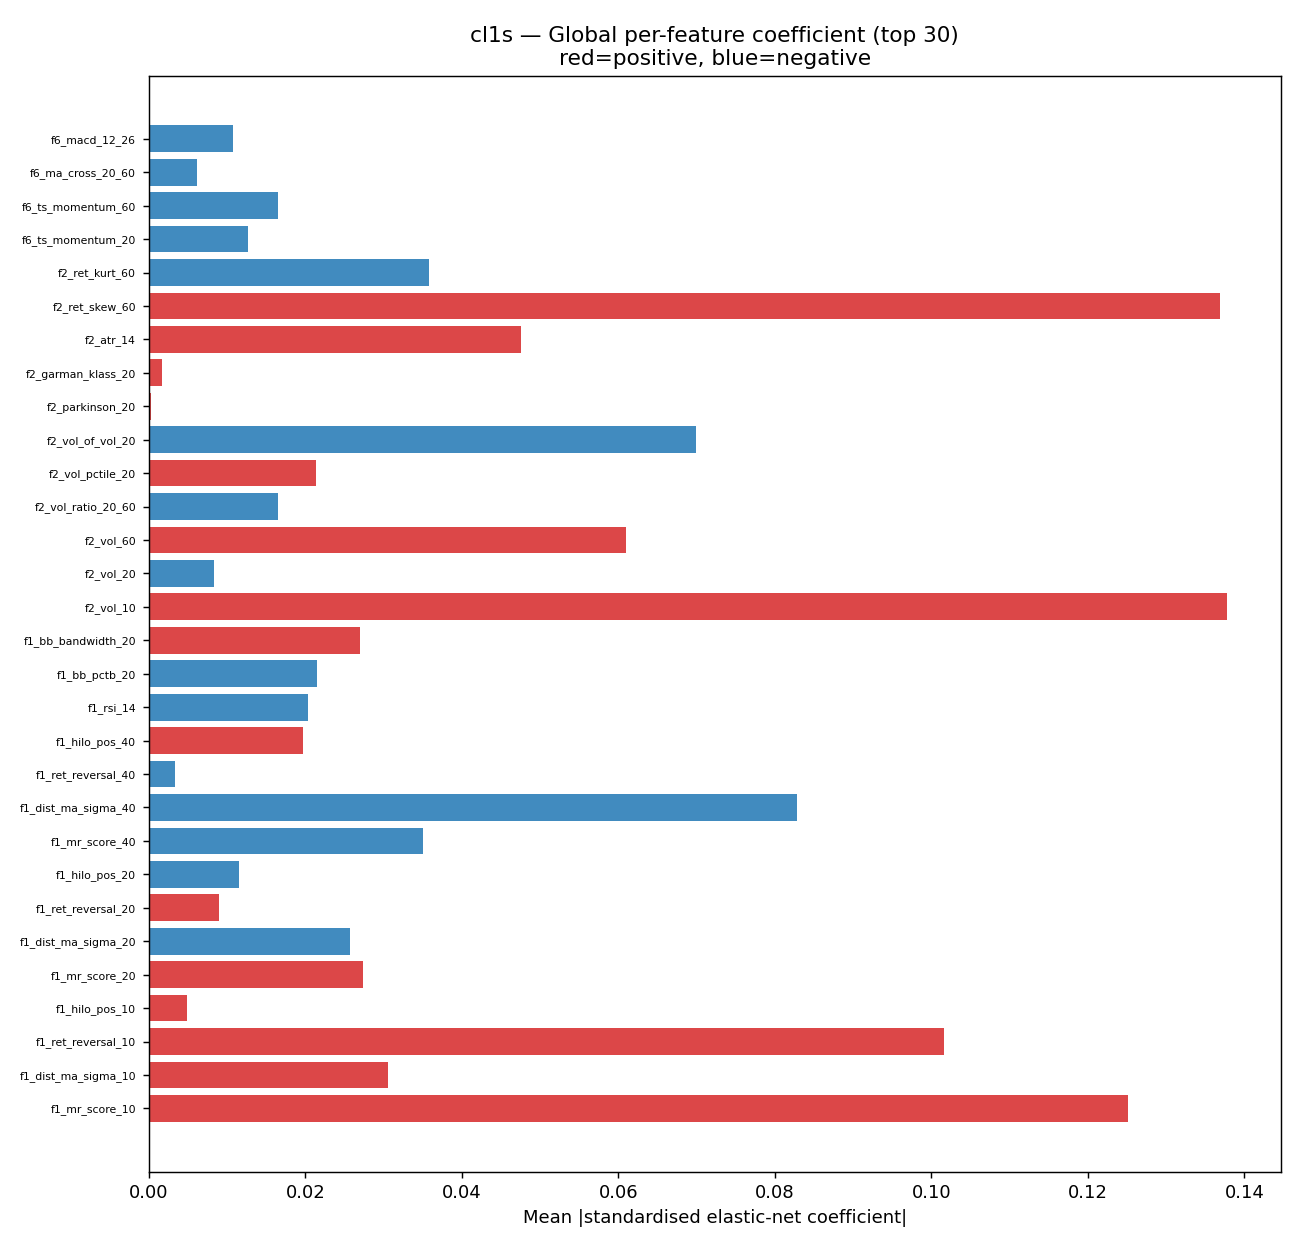

In [7]:
show_step5('cl1s')

---
### HO1S — Steps 1–5

In [ ]:
meta = print_header('ho1s')

#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
13,C8_f11_lowfreq_macro,2,f11_,100%,0.0542,0.0892,False
5,C15_f11,7,f11_,71%,0.0456,0.0468,False
6,C1_f1,9,f1_,89%,0.0410,0.0932,False
15,F4_latent,4,f4_,100%,0.0227,0.0470,False
7,C2_f6,6,f6_,33%,0.0138,0.0336,False
17,F8_calendar,4,f8_,100%,0.0122,0.0235,False
4,C14_f7,3,f7_,100%,0.0104,0.0388,False
8,C3_f1,11,f1_,36%,0.0049,0.0459,False
0,C10_f11_lowfreq_macro,2,f11_,100%,0.0031,0.0087,False
10,C5_f2,8,f2_,62%,0.0021,0.0230,False


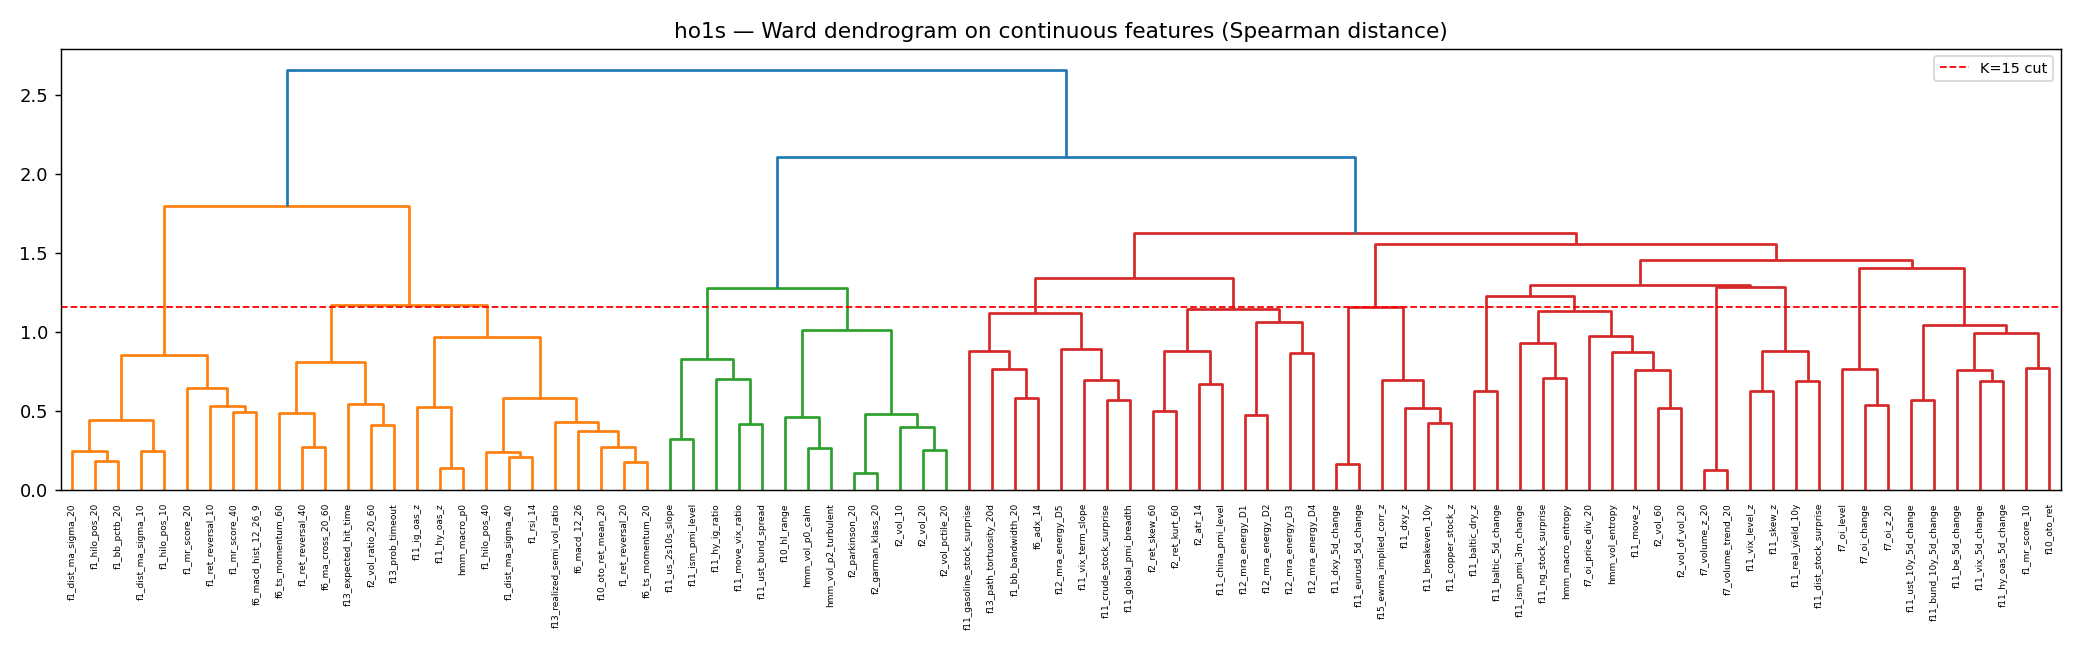

In [9]:
show_step1('ho1s')

#### Step 2 · Cluster-level importance

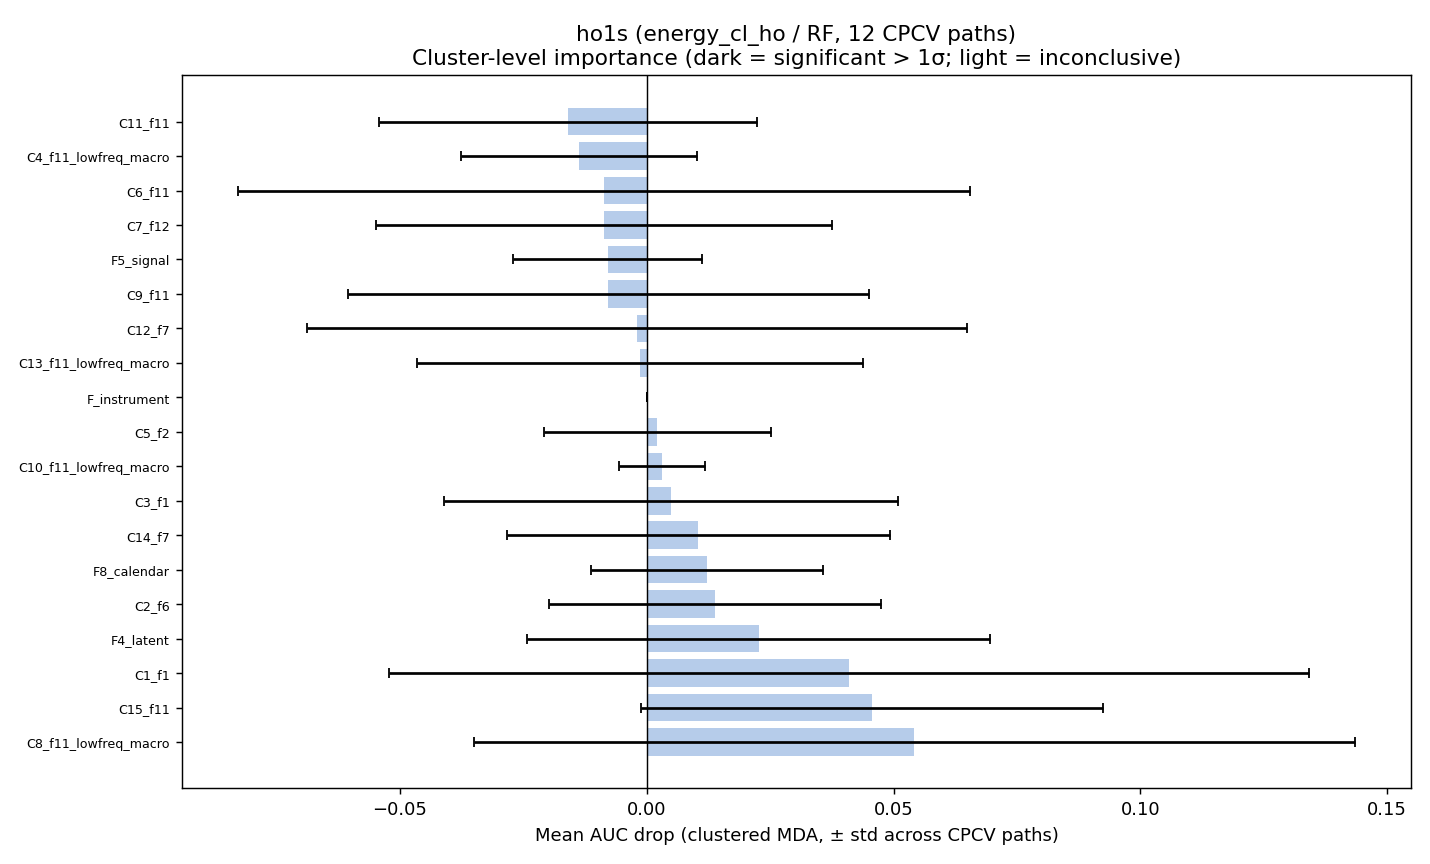

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C8_f11_lowfreq_macro,0.0542,1,0.0391,11,0.0084,10,False
1,C15_f11,0.0456,2,0.1048,3,0.0206,3,False
2,C1_f1,0.0410,3,0.1276,1,0.0255,1,False
3,F4_latent,0.0227,4,0.0395,10,0.0097,9,False
4,C2_f6,0.0138,5,0.0372,12,0.0071,13,False
5,F8_calendar,0.0122,6,0.0137,18,0.0030,18,False
6,C14_f7,0.0104,7,0.0289,15,0.0053,15,False
7,C3_f1,0.0049,8,0.0784,4,0.0125,7,False
8,C10_f11_lowfreq_macro,0.0031,9,0.0201,16,0.0034,17,False
9,C5_f2,0.0021,10,0.0733,6,0.0129,6,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.04,False
1,MDA-SHAP,0.02,False
2,MDI-SHAP,0.88,True


In [10]:
show_step2('ho1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C8_f11_lowfreq_macro', 'C15_f11', 'C1_f1']


,feature,mean_shap_mag,pc1_loading
0,f11_dxy_5d_change,0.0035,0.707
1,f11_eurusd_5d_change,0.0049,-0.707


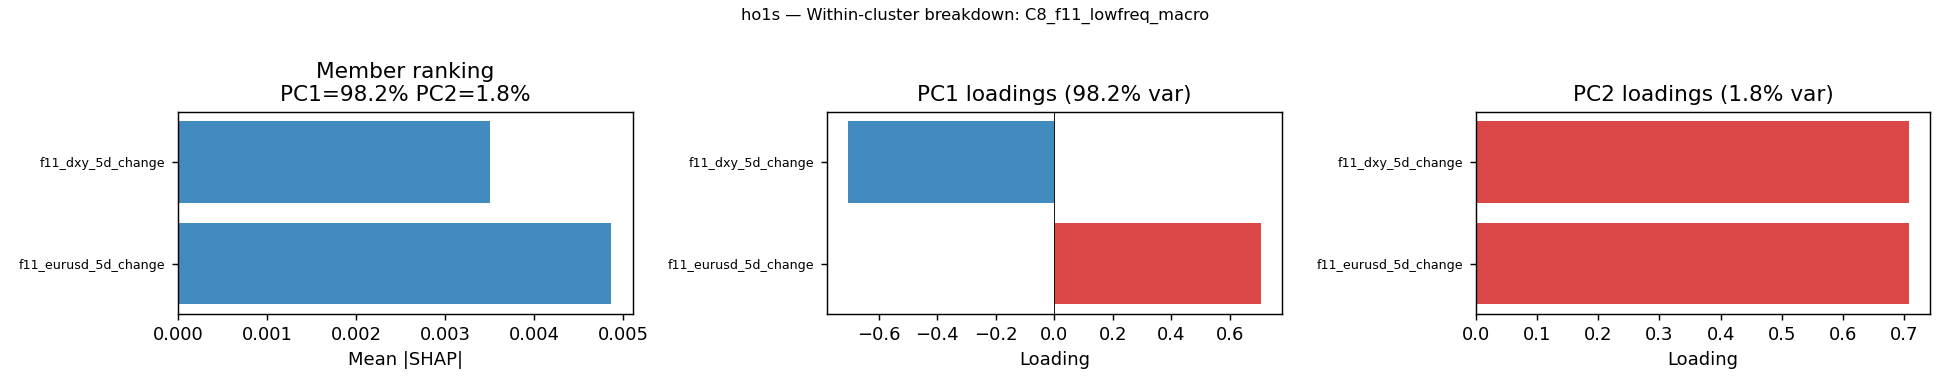

,feature,mean_shap_mag,pc1_loading
0,f1_mr_score_10,0.0034,0.393
1,f10_oto_ret,0.0045,-0.241
2,f11_vix_5d_change,0.0057,0.447
3,f11_ust_10y_5d_change,0.0014,-0.441
4,f11_bund_10y_5d_change,0.0016,-0.316
5,f11_be_5d_change,0.0024,-0.439
6,f11_hy_oas_5d_change,0.0016,0.316


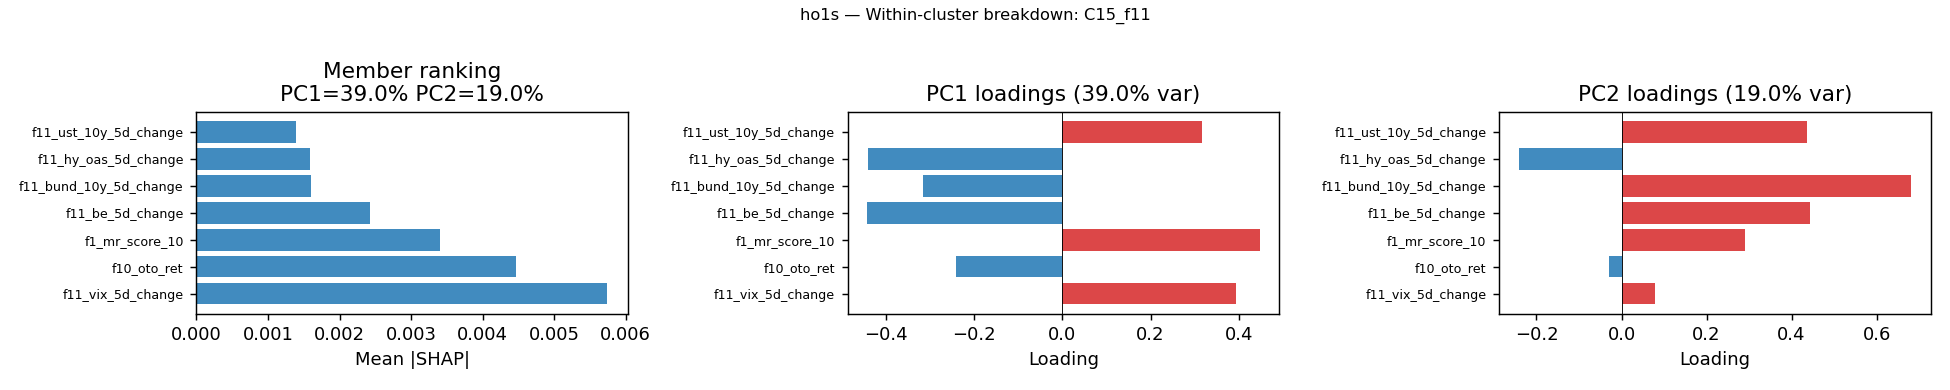

,feature,mean_shap_mag,pc1_loading
0,f1_dist_ma_sigma_10,0.0025,0.366
1,f1_ret_reversal_10,0.0032,-0.267
2,f1_hilo_pos_10,0.0033,0.365
3,f1_mr_score_20,0.0047,-0.284
4,f1_dist_ma_sigma_20,0.0020,0.357
5,f1_hilo_pos_20,0.0030,0.362
6,f1_mr_score_40,0.0035,-0.323
7,f1_bb_pctb_20,0.0025,0.373
8,f6_macd_hist_12_26_9,0.0009,0.279


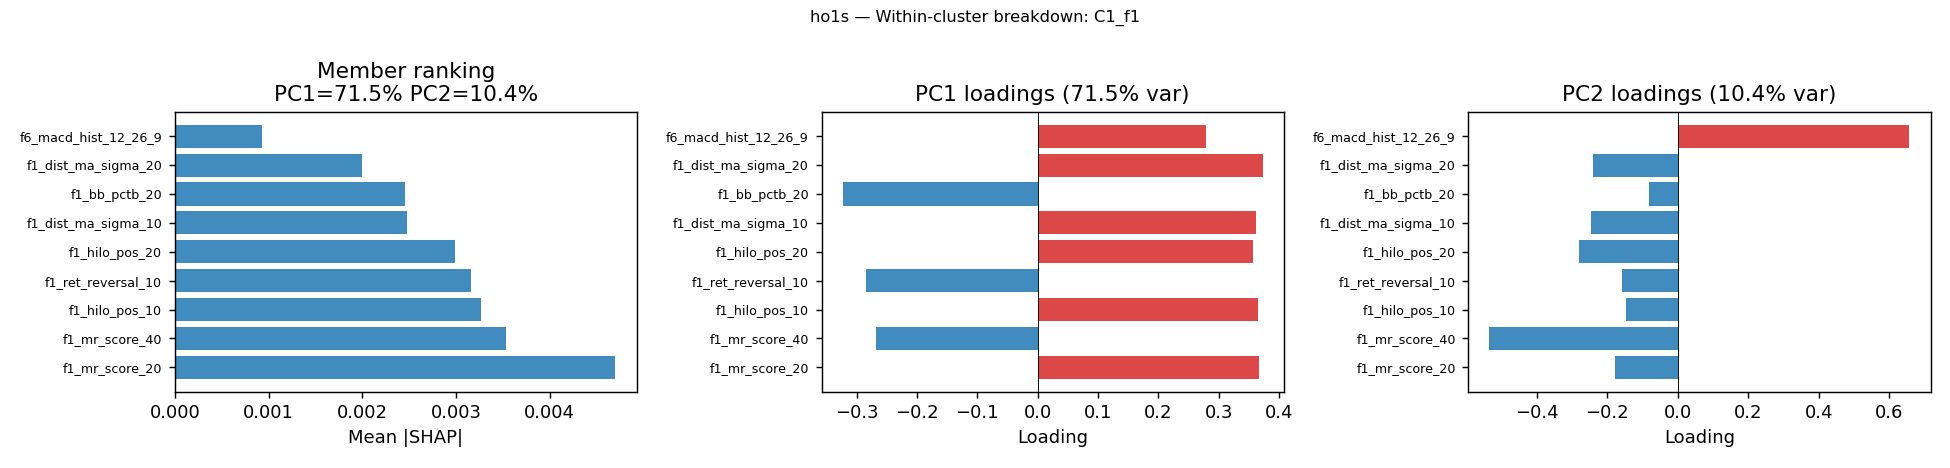

In [11]:
show_step3('ho1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f11_vix_term_slope,0.0090,-0.0007,0.0382
1,f4_pc3,0.0075,-0.0011,0.0255
2,f1_bb_bandwidth_20,0.0060,0.0010,0.0286
3,f11_vix_5d_change,0.0057,0.0011,0.0267
4,f11_real_yield_10y,0.0050,0.0024,0.0164
5,f11_eurusd_5d_change,0.0049,0.0002,0.0241
6,f1_mr_score_20,0.0047,0.0020,0.0217
7,f10_oto_ret,0.0045,0.0025,0.0198
8,f7_volume_trend_20,0.0038,0.0007,0.0180
9,f11_skew_z,0.0038,-0.0016,0.0237


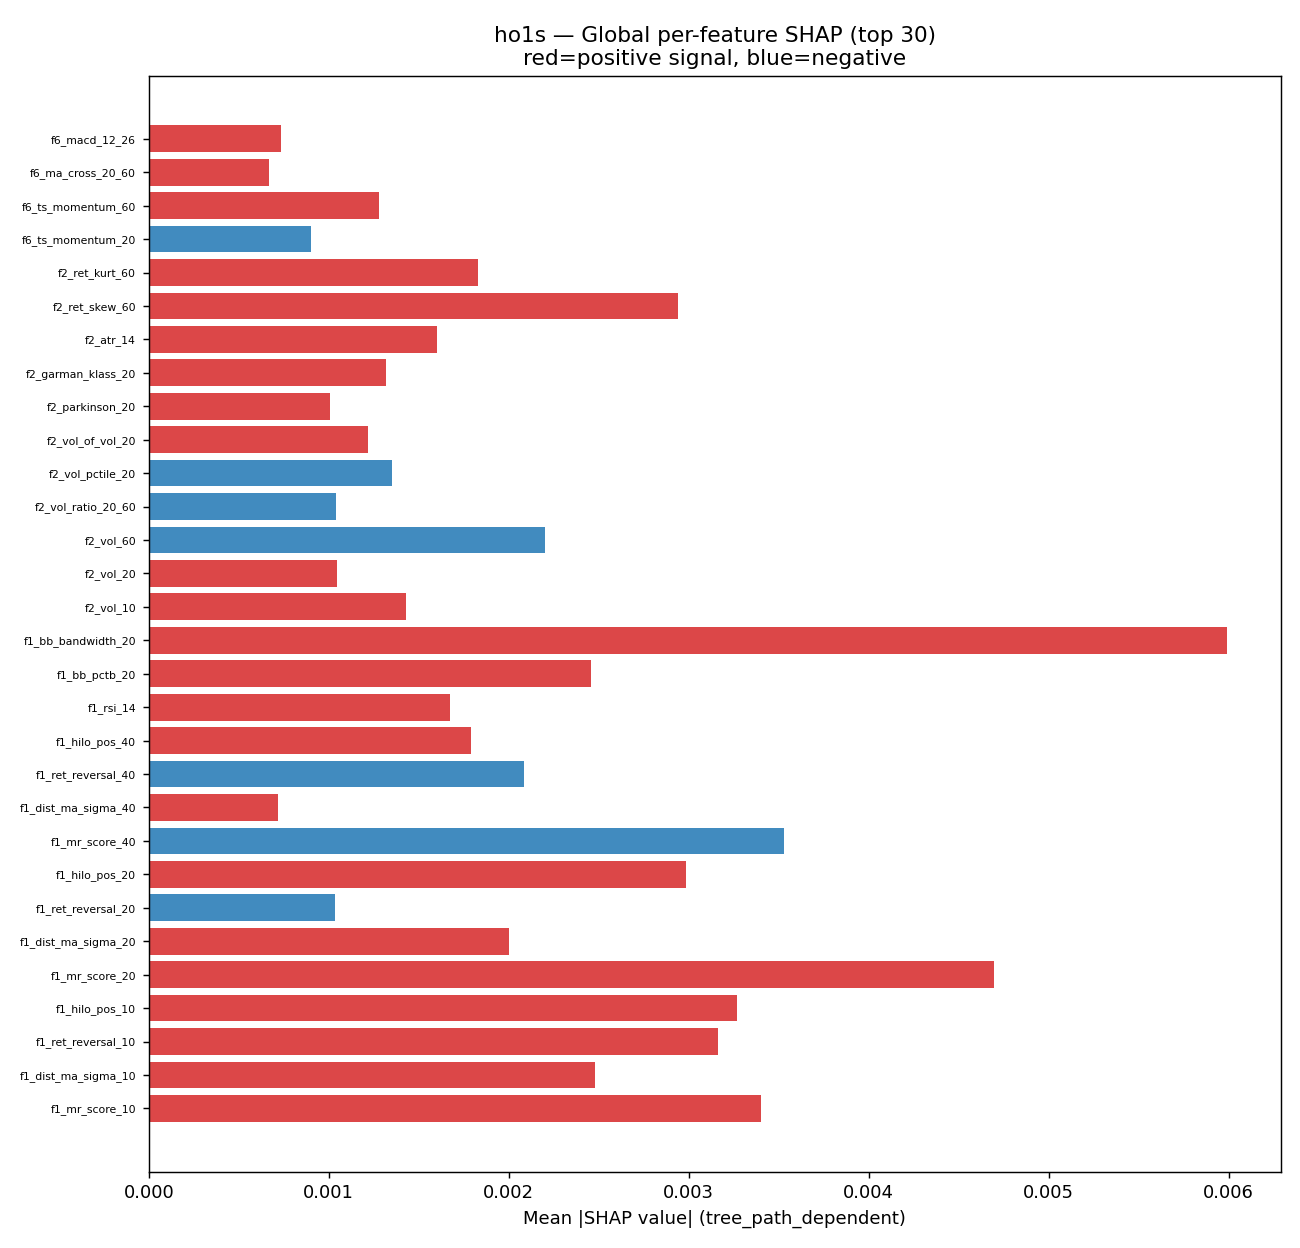

In [12]:
show_step5('ho1s')

---
### RB1S — Steps 1–5

In [13]:
meta = print_header('rb1s')

--- RB1S | group=rb1s | champion=LOGISTIC | family=logistic ---
CPCV: 15 paths  AUC 0.5773 ± 0.0710  SIGNAL (lower CI 0.5063)
Significant clusters: none


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.0292,0.0461,False
11,C6_f11_lowfreq_macro,5,f11_,100%,0.0152,0.0230,False
6,C1_f1,12,f1_,83%,0.0111,0.0239,False
8,C3_f2,14,f2_,43%,0.0104,0.0212,False
9,C4_f7,4,f7_,100%,0.0095,0.0126,False
7,C2_f6,8,f6_,50%,0.0081,0.0227,False
12,C7_f1,5,f1_,20%,0.0040,0.0077,False
2,C12_f11,5,f11_,80%,0.0034,0.0234,False
17,F8_calendar,4,f8_,100%,0.0008,0.0062,False
10,C5_f1,3,f1_,67%,0.0006,0.0047,False


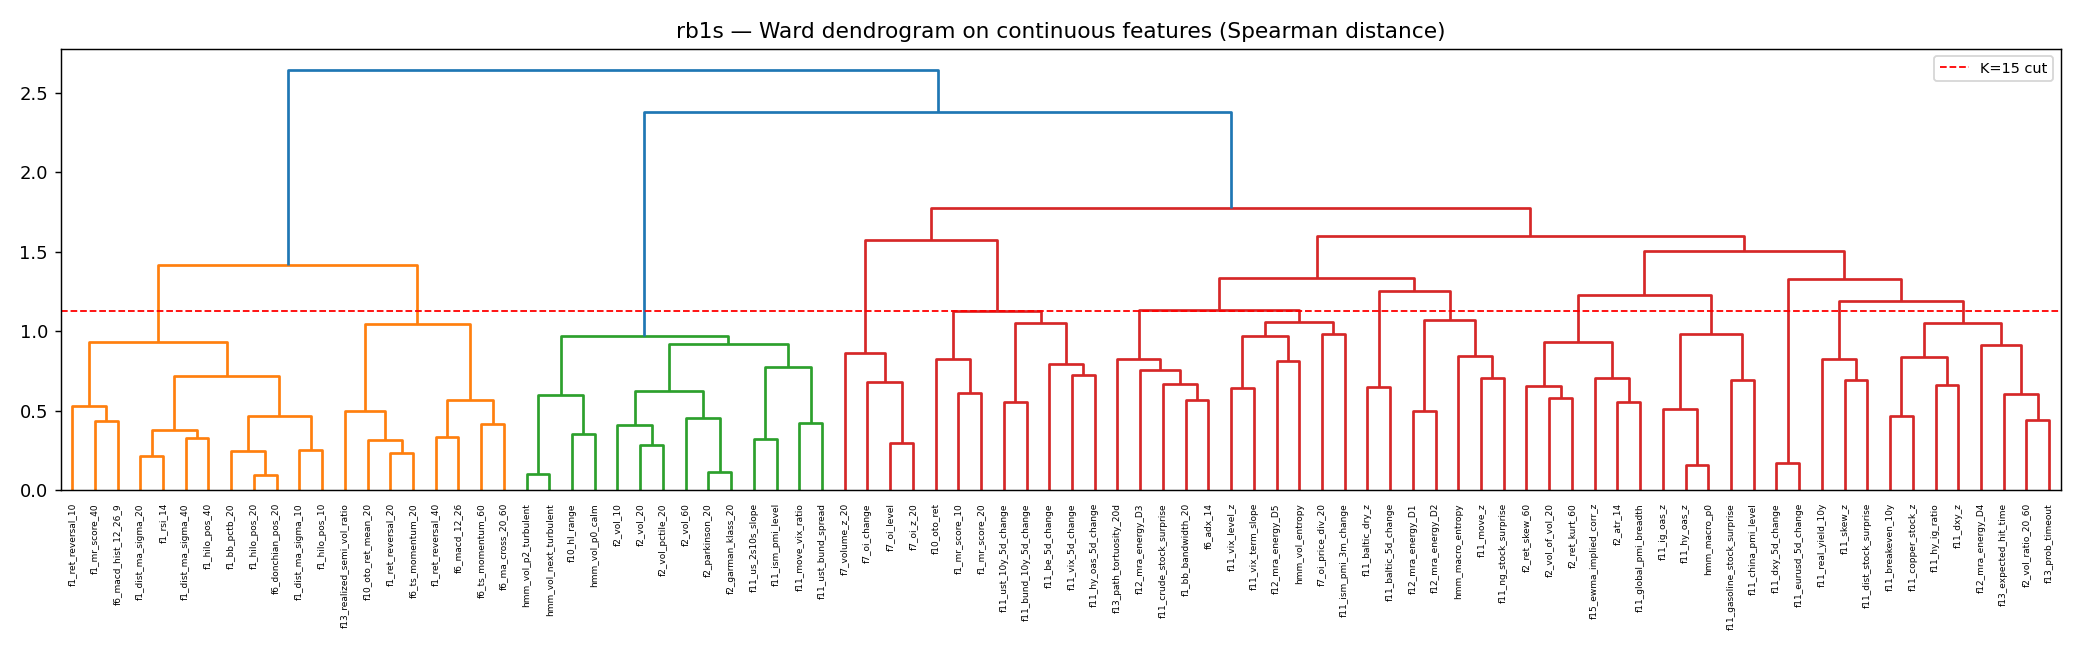

In [14]:
show_step1('rb1s')

#### Step 2 · Cluster-level importance

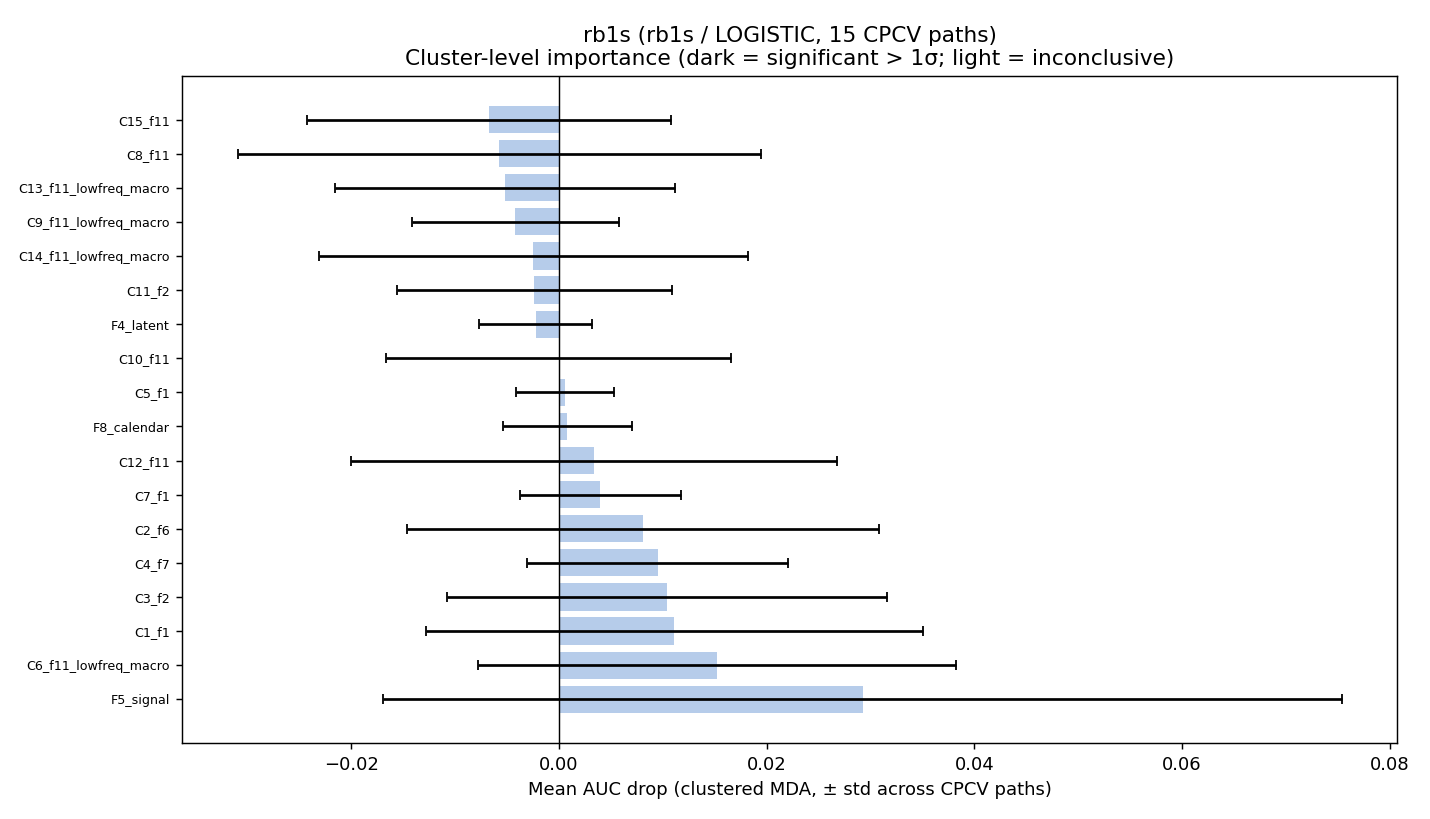

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,F5_signal,0.0292,1,0.3703,1,False
1,C6_f11_lowfreq_macro,0.0152,2,0.1937,5,False
2,C1_f1,0.0111,3,0.2179,3,False
3,C3_f2,0.0104,4,0.2214,2,False
4,C4_f7,0.0095,5,0.1278,12,False
5,C2_f6,0.0081,6,0.1235,13,False
6,C7_f1,0.0040,7,0.1351,10,False
7,C12_f11,0.0034,8,0.1455,8,False
8,F8_calendar,0.0008,9,0.0671,14,False
9,C5_f1,0.0006,10,0.0365,17,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-Coef,0.28,False


In [15]:
show_step2('rb1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['F5_signal', 'C6_f11_lowfreq_macro', 'C1_f1']


,feature,mean_coef_abs,pc1_loading
0,f5_signal,0.2589,0.544
1,f5_trailing_run_length,0.0185,0.498
2,f5_participation_20,0.0435,0.312
3,f5_long_bias_20,0.0009,0.587
4,f5_sign_agree_mr,0.0107,-0.119


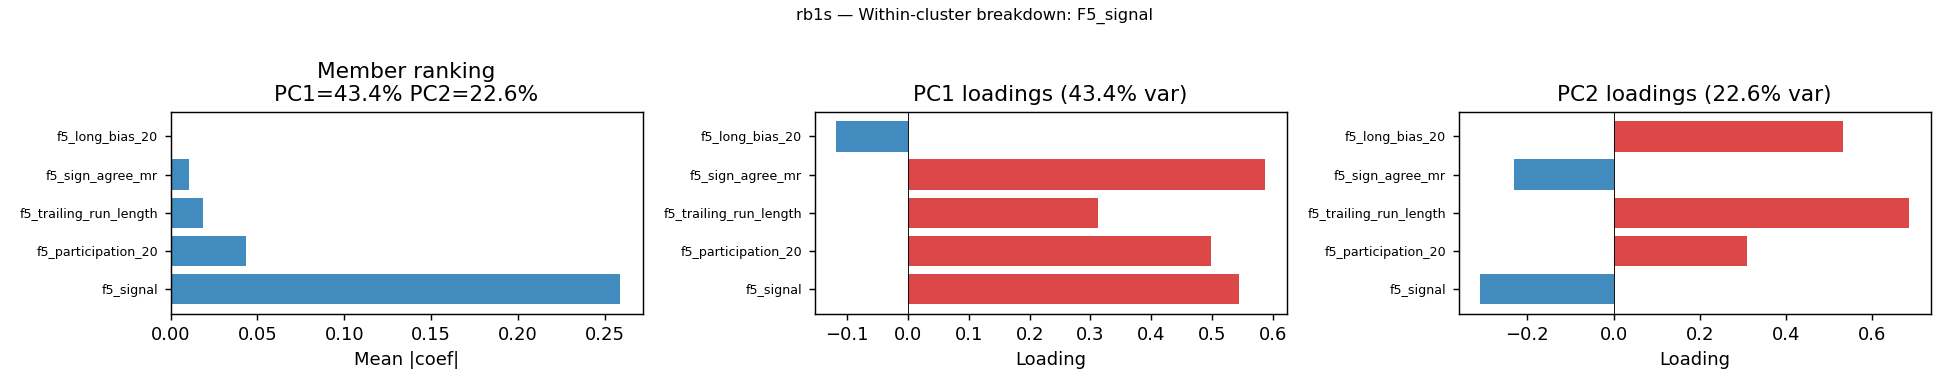

,feature,mean_coef_abs,pc1_loading
0,f11_vix_5d_change,0.0048,-0.539
1,f11_ust_10y_5d_change,0.0039,0.388
2,f11_bund_10y_5d_change,0.0154,0.221
3,f11_be_5d_change,0.0083,0.554
4,f11_hy_oas_5d_change,0.1497,-0.451


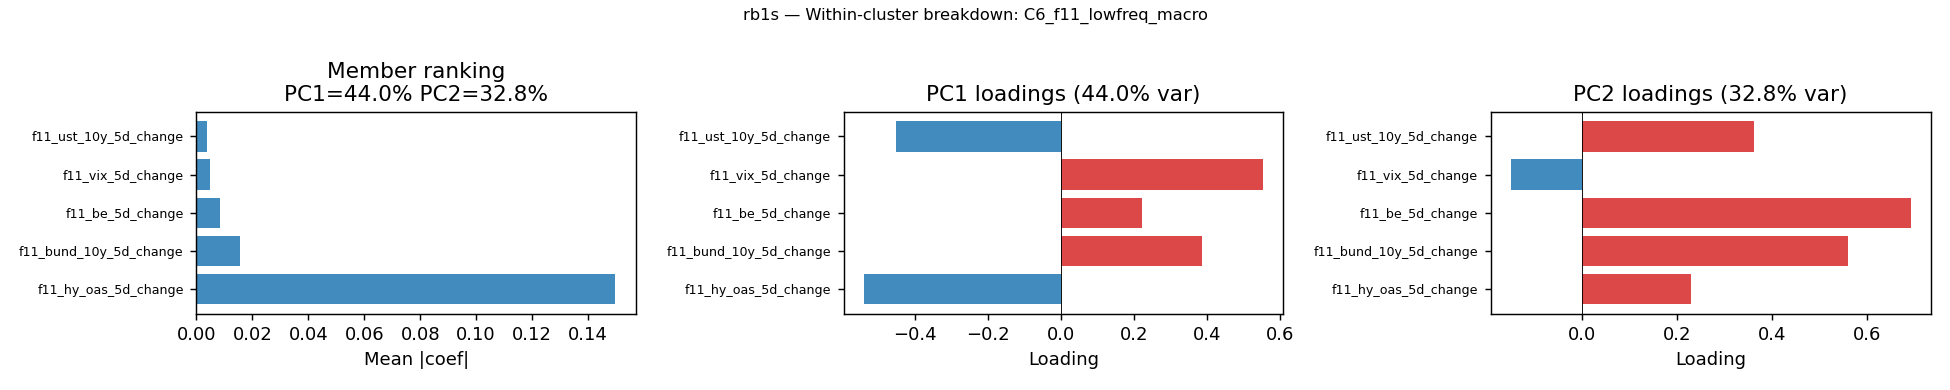

,feature,mean_coef_abs,pc1_loading
0,f1_dist_ma_sigma_10,0.0081,0.305
1,f1_ret_reversal_10,0.0207,-0.239
2,f1_hilo_pos_10,0.0058,0.286
3,f1_dist_ma_sigma_20,0.0072,0.312
4,f1_hilo_pos_20,0.0172,0.315
5,f1_mr_score_40,0.0153,-0.285
6,f1_dist_ma_sigma_40,0.0373,0.270
7,f1_hilo_pos_40,0.0489,0.283
8,f1_rsi_14,0.0164,0.303
9,f1_bb_pctb_20,0.0135,0.319


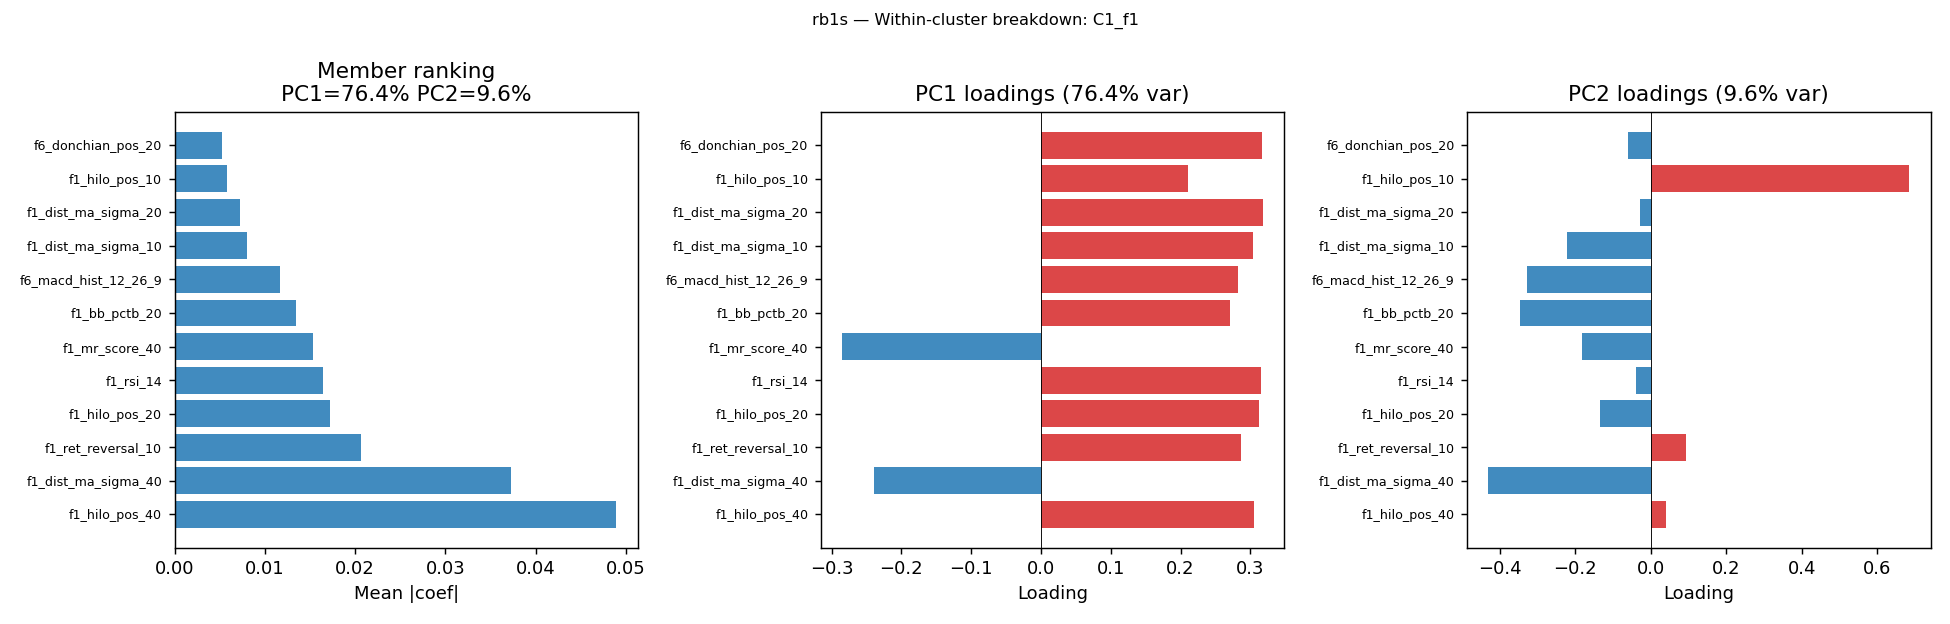

In [16]:
show_step3('rb1s')

#### Step 5 · Global feature importance

,feature,coef_abs,coef_signed
0,f5_signal,0.2589,0.2589
1,f11_hy_oas_5d_change,0.1497,0.1497
2,f12_mra_energy_D2,0.0846,0.0846
3,f11_dist_stock_surprise,0.0838,0.0838
4,f11_gasoline_stock_surprise,0.0735,0.0735
5,hmm_vol_p0_calm,0.0720,-0.0720
6,f11_crude_stock_surprise,0.0707,0.0707
7,f2_vol_ratio_20_60,0.0695,-0.0695
8,f7_oi_level,0.0589,-0.0589
9,f11_dxy_z,0.0563,0.0563


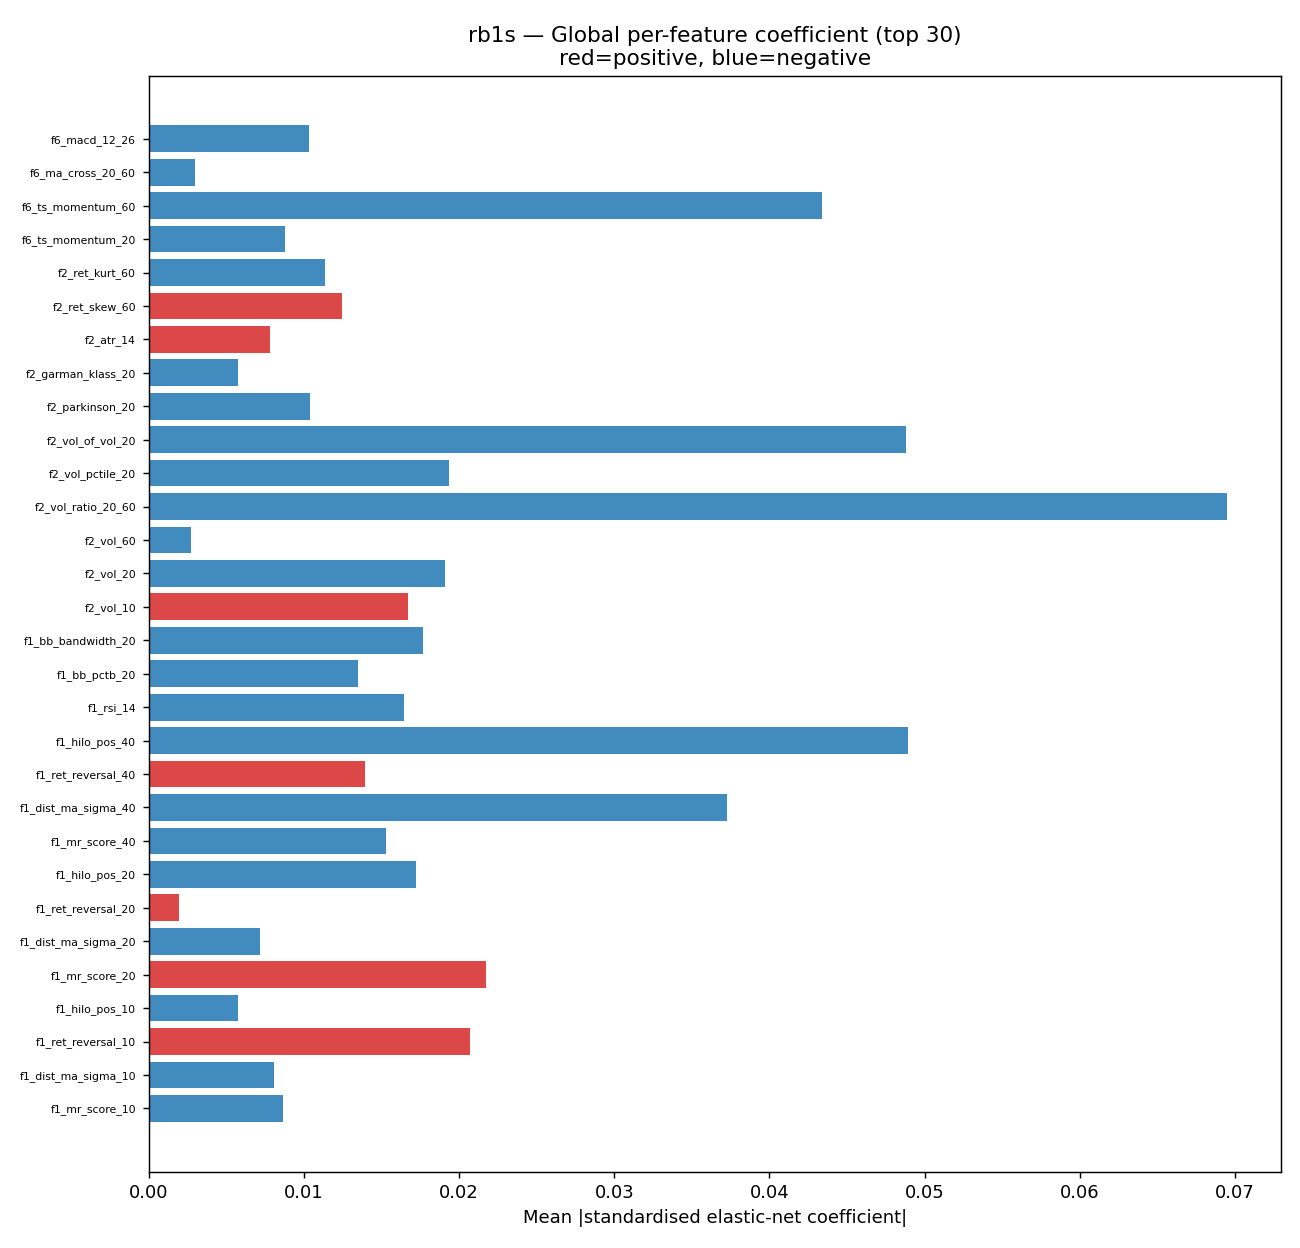

In [17]:
show_step5('rb1s')

---
### NG1S — Steps 1–5

In [18]:
meta = print_header('ng1s')

--- NG1S | group=energy_all | champion=RF | family=tree ---
CPCV: 12 paths  AUC 0.6576 ± 0.1389  SIGNAL (lower CI 0.5187)
Significant clusters: C15_f7 (MDA 0.1088 ± 0.0633)


#### Step 1 · Feature clusters

,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
5,C15_f7,4,f7_,75%,0.1088,0.0633,True
0,C10_f11_lowfreq_macro,6,f11_,100%,0.0618,0.0992,False
9,C4_f2,15,f2_,47%,0.0551,0.0751,False
7,C2_f1,10,f1_,70%,0.0480,0.1320,False
18,F_instrument,3,inst_,100%,0.0476,0.1089,False
10,C5_f11,7,f11_,71%,0.0468,0.0615,False
16,F5_signal,5,f5_,100%,0.0461,0.1086,False
12,C7_f11,10,f11_,30%,0.0343,0.1162,False
13,C8_f11_lowfreq_macro,2,f11_,100%,0.0292,0.0572,False
8,C3_f6,7,f6_,43%,0.0248,0.0599,False


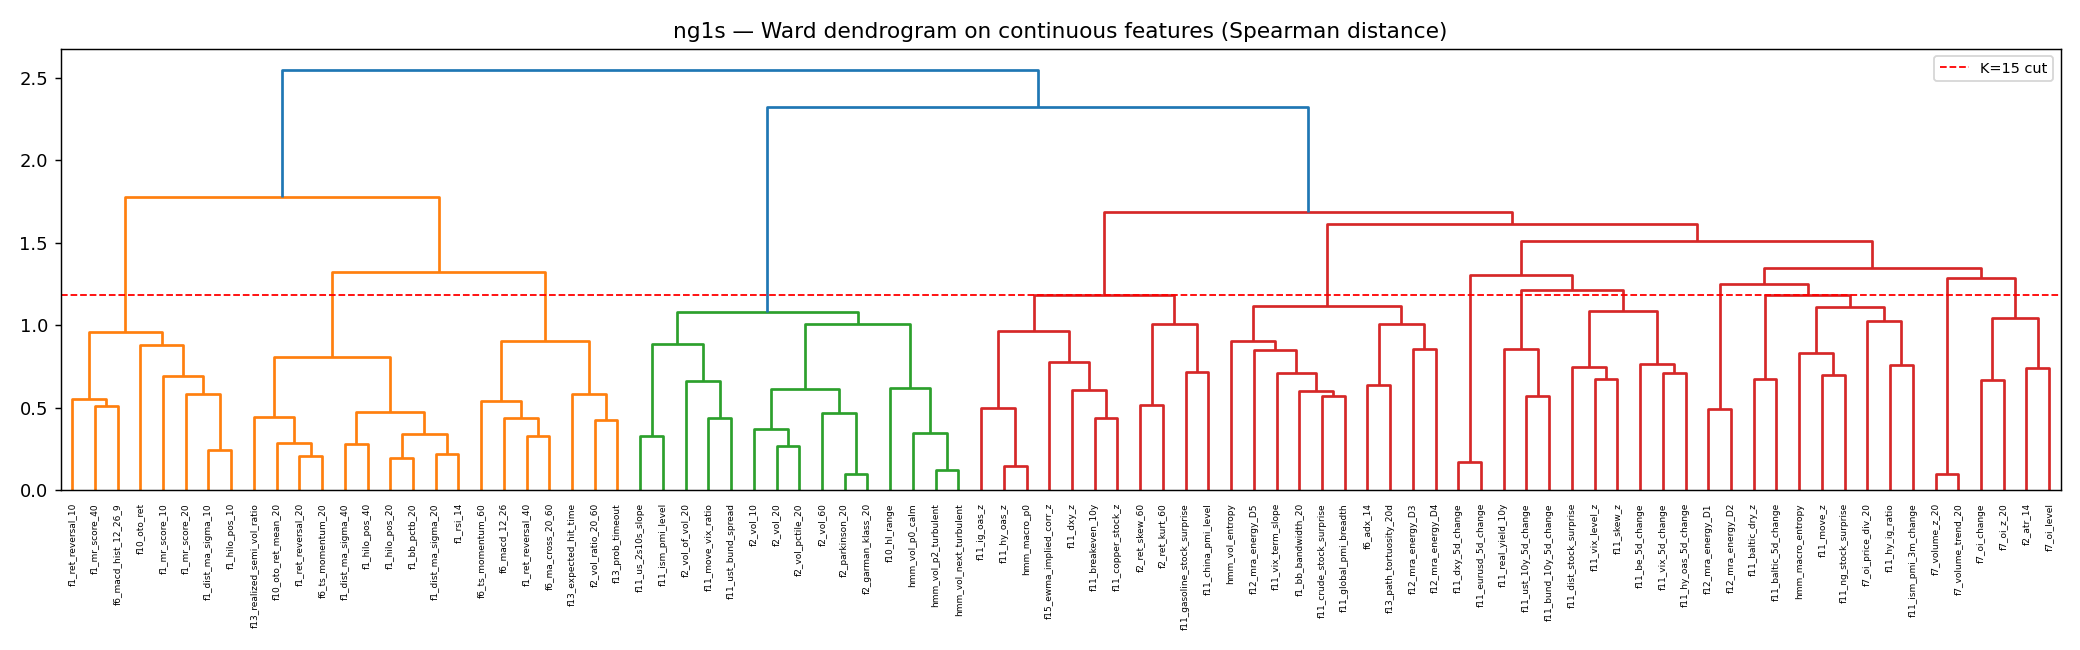

In [19]:
show_step1('ng1s')

#### Step 2 · Cluster-level importance

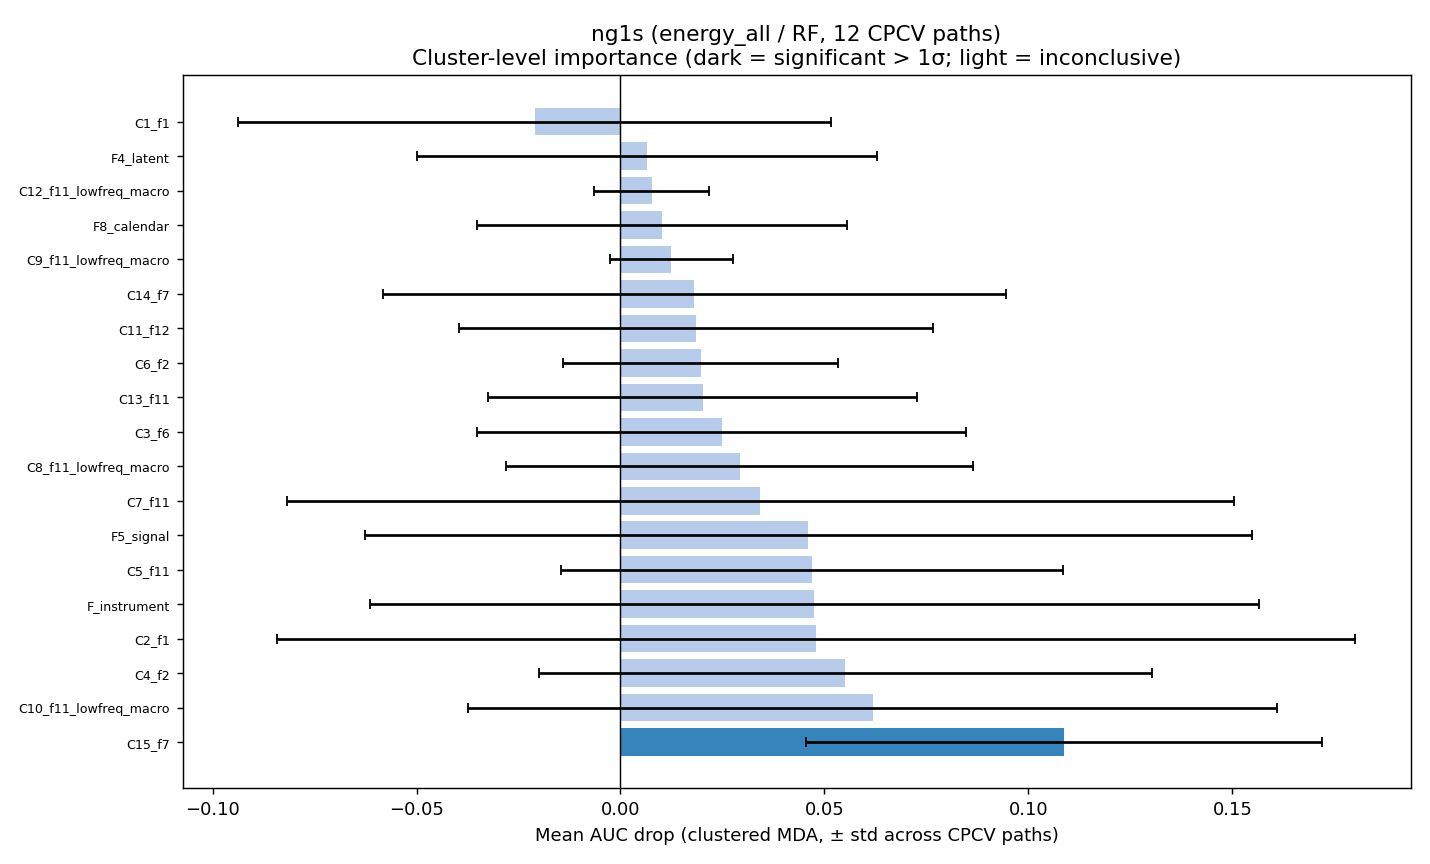

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C15_f7,0.1088,1,0.2264,1,0.0519,1,True
1,C10_f11_lowfreq_macro,0.0618,2,0.0364,9,0.0077,9,False
2,C4_f2,0.0551,3,0.1795,2,0.0282,3,False
3,C2_f1,0.0480,4,0.0630,5,0.0112,5,False
4,F_instrument,0.0476,5,0.0861,4,0.0152,4,False
5,C5_f11,0.0468,6,0.0539,6,0.0085,8,False
6,F5_signal,0.0461,7,0.0942,3,0.0289,2,False
7,C7_f11,0.0343,8,0.0538,7,0.0111,6,False
8,C8_f11_lowfreq_macro,0.0292,9,0.0177,14,0.0033,14,False
9,C3_f6,0.0248,10,0.0291,10,0.0046,12,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.60,True
1,MDA-SHAP,0.50,True
2,MDI-SHAP,0.89,True


In [20]:
show_step2('ng1s')

#### Step 3 · Within-cluster breakdown (top 3, significant first)

Step-3 clusters (significant first): ['C15_f7', 'C10_f11_lowfreq_macro', 'C4_f2']


,feature,mean_shap_mag,pc1_loading
0,f2_atr_14,0.0160,-0.487
1,f7_oi_level,0.0162,0.663
2,f7_oi_change,0.0191,0.372
3,f7_oi_z_20,0.0006,0.430


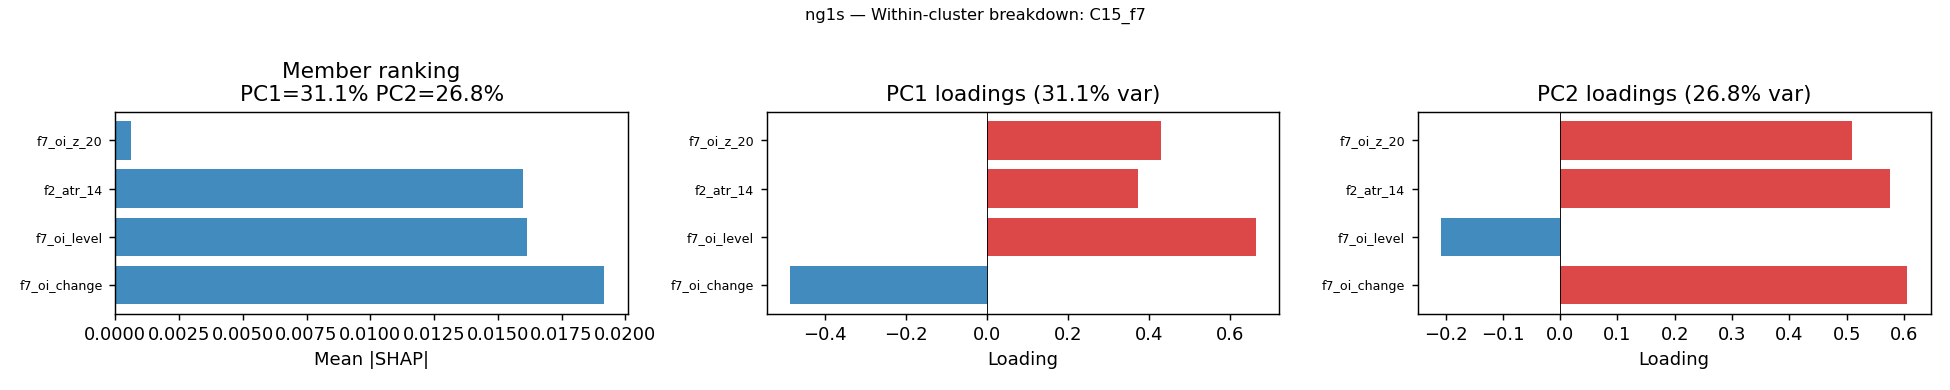

,feature,mean_shap_mag,pc1_loading
0,f11_vix_level_z,0.0011,0.495
1,f11_vix_5d_change,0.0019,0.451
2,f11_skew_z,0.0009,-0.360
3,f11_be_5d_change,0.0009,-0.393
4,f11_hy_oas_5d_change,0.0013,0.417
5,f11_dist_stock_surprise,0.0017,-0.306


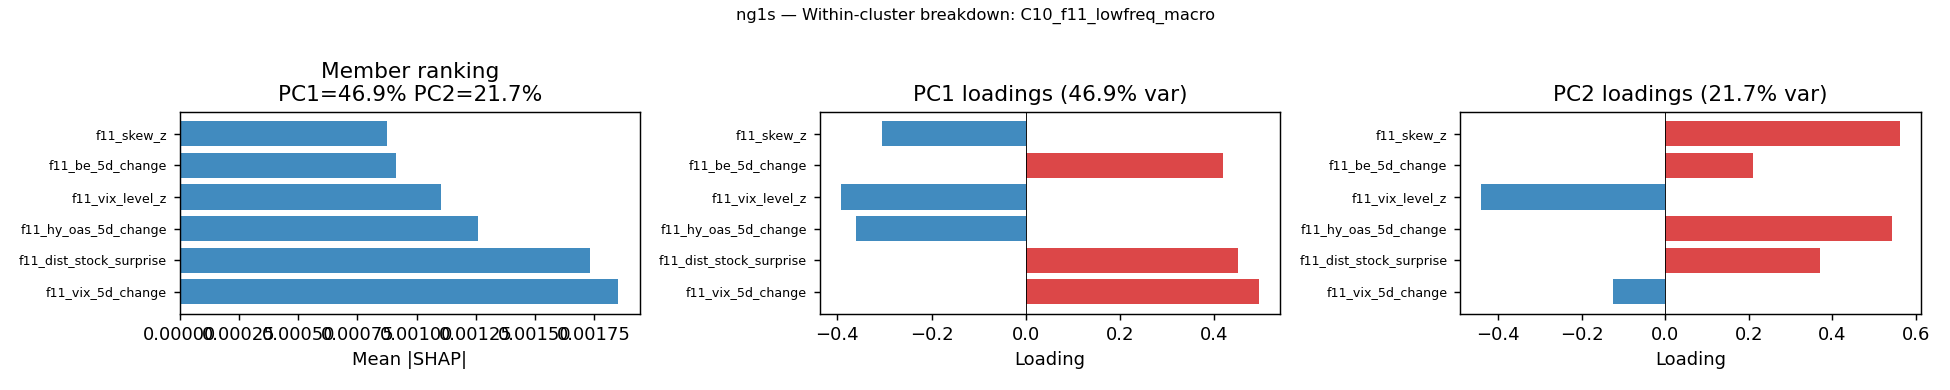

,feature,mean_shap_mag,pc1_loading
0,f2_vol_10,0.0003,0.281
1,f2_vol_20,0.0009,0.303
2,f2_vol_60,0.0011,0.295
3,f2_vol_pctile_20,0.0009,0.257
4,f2_vol_of_vol_20,0.0009,0.259
5,f2_parkinson_20,0.0006,0.298
6,f2_garman_klass_20,0.0005,0.296
7,f10_hl_range,0.0006,0.215
8,f11_move_vix_ratio,0.0004,-0.199
9,f11_us_2s10s_slope,0.0005,-0.216


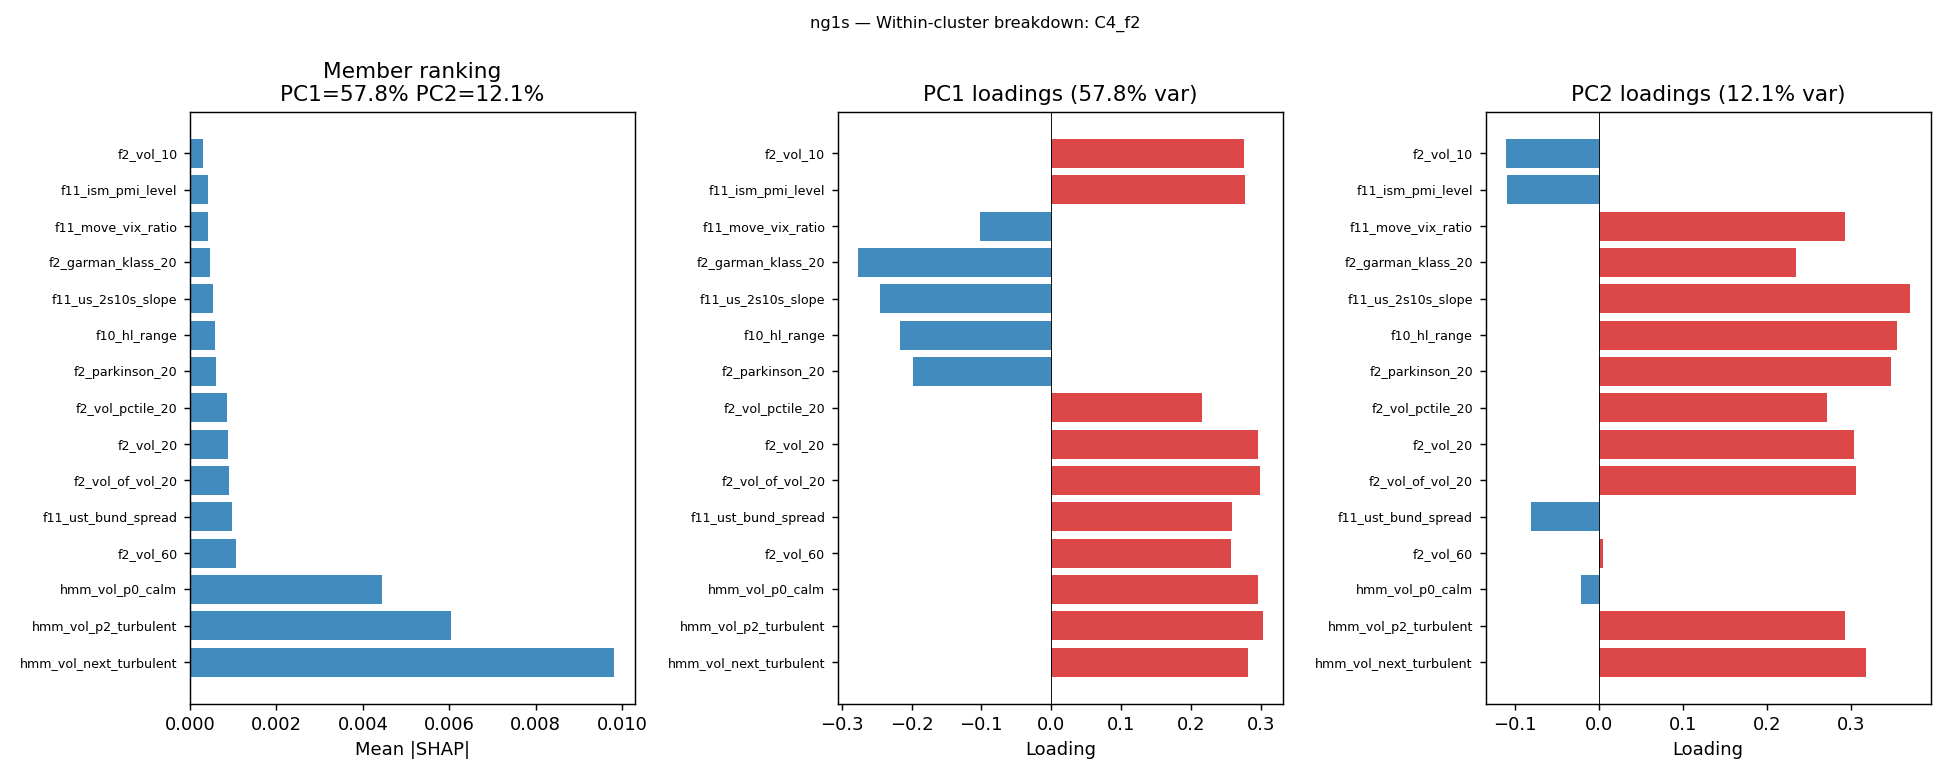

In [21]:
show_step3('ng1s')

#### Step 5 · Global feature importance

,feature,shap_magnitude,shap_signed,mdi
0,f7_oi_change,0.0191,0.0135,0.0680
1,f7_oi_level,0.0162,0.0162,0.0887
2,f2_atr_14,0.0160,-0.0160,0.0657
3,inst_rb1s,0.0152,0.0152,0.0860
4,f5_signal,0.0134,-0.0134,0.0305
5,hmm_vol_next_turbulent,0.0098,0.0098,0.0615
6,f5_participation_20,0.0091,0.0091,0.0362
7,hmm_vol_p2_turbulent,0.0061,0.0061,0.0332
8,f5_long_bias_20,0.0054,-0.0049,0.0225
9,hmm_vol_p0_calm,0.0045,0.0045,0.0381


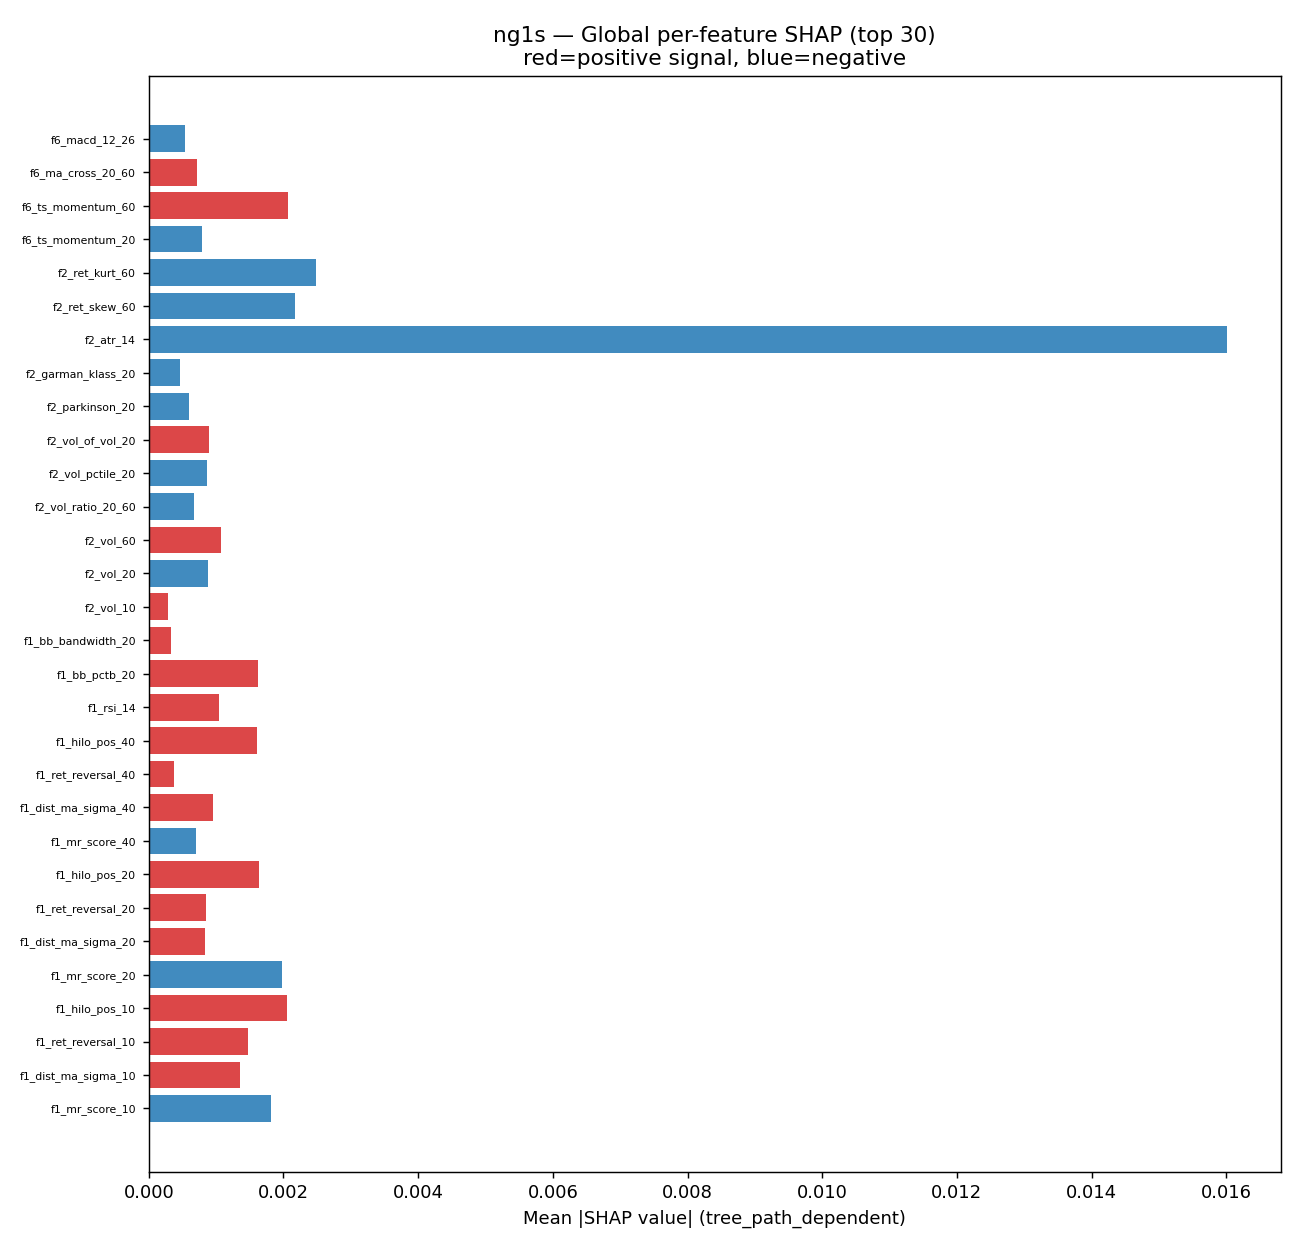

In [22]:
show_step5('ng1s')

---
## Cross-instrument findings — energy

In [ ]:
# Cross-instrument summary — all values from champion_meta + clustered_mda_full
INSTS = ['cl1s', 'ho1s', 'rb1s', 'ng1s']

rows = []
for inst in INSTS:
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    if not m:
        continue
    sig = mda[mda['significant']] if not mda.empty else pd.DataFrame()
    rows.append({
        'inst'          : inst,
        'group'         : m.get('group', '?'),
        'champion'      : m.get('model_type', '?').upper(),
        'family'        : m.get('family', '?'),
 False) else '\u2717',
        'AUC'           : f"{m.get('auc_mean', 0):.4f}\u00b1{m.get('auc_std', 0):.4f}",
        'lower_CI'      : f"{m.get('lower_ci', 0):.4f}",
        'n_sig_clusters': int(len(sig)),
        'top_cluster'   : mda.iloc[0]['cluster'] if not mda.empty else '?',
        'top_mda'       : f"{mda.iloc[0]['mean_drop']:.4f}" if not mda.empty else '?',
        '\u03c4_primary' : (f"{ra['kendall_tau'].iloc[0]:.2f}"
                           if not ra.empty else 'n/a'),
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Energy champions — cross-instrument summary (all values computed)')
)

print('\nTop-5 MDA per instrument:')
for inst in INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    m   = get_meta(inst)
    if mda.empty:
        continue
    print(mda[['cluster','mean_drop','std_drop','significant']].head(5).to_string(index=False))


---
## Consistency assertions

In [24]:
# ── CONSISTENCY ASSERTIONS ─────────────────────────────────────────────────
# (a/b/c) champion_meta matches selection_table
# (d)     Step-3 cluster names == names in clustered_mda_full
# (e)     Step-3 cluster IDs exist in cluster_membership.csv
# (f)     AUC in champion_meta self-consistent (trivially true; verified here for completeness)

INSTS = ['cl1s', 'ho1s', 'rb1s', 'ng1s']
errors = []

for inst in INSTS:
    s   = sel.loc[inst]
    m   = get_meta(inst)
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    mem = load(BASE / inst / 'cluster_membership.csv')

    if not m:
        errors.append(f'{inst}: champion_meta.csv missing or empty')
        continue

    # (a/b/c) model type — RF surrogate is accepted when selection champion is MLP
    meta_model, sel_model = m.get('model_type',''), s['best_model']
    is_mlp_rf_surrogate = (sel_model == 'mlp' and meta_model == 'rf')
    if meta_model != sel_model and not is_mlp_rf_surrogate:
        errors.append(
            f'{inst}: champion_meta model_type={meta_model!r} '
            f'!= selection_table best_model={sel_model!r}'
        )

    # AUC match
    meta_auc = round(float(m.get('auc_mean', -1)), 4)
    sel_auc  = round(float(s['best_auc']), 4)
    if abs(meta_auc - sel_auc) > 0.0001:
        errors.append(
            f'{inst}: champion_meta auc_mean={meta_auc} '
            f'!= selection_table best_auc={sel_auc}'
        )

    if mda.empty:
        errors.append(f'{inst}: clustered_mda_full.csv missing')
        continue

    # (d) Step-3 clusters come from the same MDA table
    step3   = top_n_clusters(inst, n=3)
    mda_set = set(mda['cluster'].tolist())
    for c in step3:
        if c not in mda_set:
            errors.append(f'{inst}: Step-3 cluster {c!r} not in clustered_mda_full.csv')

    # All significant clusters shown (assuming ≤ 3 significant)
    sig_set = set(mda[mda['significant']]['cluster'].tolist())
    shown   = set(step3)
    if len(sig_set) <= 3 and not sig_set.issubset(shown):
        missing = sig_set - shown
        errors.append(f'{inst}: significant clusters {missing} not shown in Step-3')

    # (e) cluster IDs exist in cluster_membership.csv
    if not mem.empty:
        mem_clusters = set(mem['cluster'].unique())
        for c in step3:
            if c not in mem_clusters:
                errors.append(f'{inst}: Step-3 cluster {c!r} not in cluster_membership.csv')

    # (f) AUC fields in champion_meta are internally consistent
    auc_m = m.get('auc_mean', float('nan'))
    lci_m = m.get('lower_ci', float('nan'))
    if not math.isnan(auc_m) and not math.isnan(lci_m) and lci_m > auc_m:
        errors.append(f'{inst}: lower_ci={lci_m} > auc_mean={auc_m} (impossible)')

if errors:
    print('ASSERTION FAILURES:')
    for e in errors:
        print(f'  \u2717 {e}')
    raise AssertionError(f'{len(errors)} assertion(s) failed — see above')
else:
    print(f'\u2713 All assertions passed for {INSTS}')


✓ All assertions passed for ['cl1s', 'ho1s', 'rb1s', 'ng1s']
